In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")

import os
import gc
import random
import math
import json
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils import clip_grad_norm_

from transformers import (
    AutoTokenizer,
    XLMRobertaModel,
    XLMRobertaConfig,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 1B
# Download previous Kaggle notebook output into this notebook
# ==========================================================

print("Starting cell #1B")

# This downloads the output files from your previous Kaggle notebook:
# kaggle kernels output sajedulislamsajid/custom-model -p /path/to/dest
# The checkpoint search cell later searches /kaggle/working recursively,
# so saving here lets the notebook find best_student.pt and best_teacher.pt automatically.

import subprocess
import shutil
from pathlib import Path

DOWNLOAD_PREVIOUS_KERNEL_OUTPUT = True
PREVIOUS_KERNEL_SLUG = "sajedulislamsajid/custom-model"
PREVIOUS_KERNEL_OUTPUT_DIR = "/kaggle/working/previous_custom_model_output"

Path(PREVIOUS_KERNEL_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

def list_downloaded_checkpoints(root_dir):
    root = Path(root_dir)
    checkpoint_names = [
        "student_model_state_dict.pt",
        "best_student.pt",
        "best_teacher.pt"
    ]
    found = []
    for name in checkpoint_names:
        found.extend([str(p) for p in root.rglob(name)])
    return sorted(set(found))

existing_checkpoints = list_downloaded_checkpoints(PREVIOUS_KERNEL_OUTPUT_DIR)

if DOWNLOAD_PREVIOUS_KERNEL_OUTPUT:
    if existing_checkpoints:
        print("Previous kernel output already appears to be downloaded.")
        print("Found checkpoints:")
        for path in existing_checkpoints:
            print(" -", path)
    else:
        if shutil.which("kaggle") is None:
            raise RuntimeError(
                "Kaggle CLI was not found. In Kaggle Notebook, the kaggle command should usually be available."
            )

        command = [
            "kaggle", "kernels", "output",
            PREVIOUS_KERNEL_SLUG,
            "-p", PREVIOUS_KERNEL_OUTPUT_DIR
        ]

        print("Running command:", " ".join(command))
        result = subprocess.run(command, text=True, capture_output=True)

        print("STDOUT:")
        print(result.stdout)

        if result.stderr.strip():
            print("STDERR:")
            print(result.stderr)

        if result.returncode != 0:
            raise RuntimeError(
                "Failed to download previous Kaggle kernel output. "
                "Check that the kernel slug is correct and that your account has access to it."
            )

        downloaded_checkpoints = list_downloaded_checkpoints(PREVIOUS_KERNEL_OUTPUT_DIR)
        print("Downloaded checkpoints found:")
        for path in downloaded_checkpoints:
            print(" -", path)

        if not downloaded_checkpoints:
            print(
                "Warning: download completed, but no .pt checkpoints were found. "
                "Open the downloaded folder and confirm the previous notebook output contains best_student.pt and best_teacher.pt."
            )
else:
    print("DOWNLOAD_PREVIOUS_KERNEL_OUTPUT=False, skipping download.")

print("Executed cell #1B")


Starting cell #1B
Running command: kaggle kernels output sajedulislamsajid/custom-model -p /kaggle/working/previous_custom_model_output
STDOUT:
Output file downloaded to /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/best_student.pt
Output file downloaded to /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/best_teacher.pt
Output file downloaded to /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/student_model_state_dict.pt
Output file downloaded to /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/tokenizer.json
Output file downloaded to /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/tokenizer_config.json
Output file downloaded to /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/training_config.json
Kernel log downloaded to /kaggle/working/previous_custom_model_output/

In [3]:
# ==========================================================
# CELL 2
# Set Kaggle dataset file names and dataset discovery hint
# ==========================================================

print("Starting cell #2")

TRAIN_FILE_NAME = "train.csv"
VALIDATION_FILE_NAME = "validation.csv"
TEST_FILE_NAME = "test.csv"

KAGGLE_INPUT_ROOT = "/kaggle/input"
DATASET_FOLDER_HINT = "Dataset"

print("Executed cell #2")

Starting cell #2
Executed cell #2


In [4]:
# ==========================================================
# CELL 3
# Set model hyperparameters, training settings, and save directory
# Teacher-student KD + full coverage then balanced SupCon
# ==========================================================

print("Starting cell #3")

# -----------------------------
# Backbone
# -----------------------------
TEACHER_MODEL_NAME = "xlm-roberta-base"

# -----------------------------
# Student architecture
# 6-layer student initialized from distributed teacher layers
# instead of only first 6 layers
# -----------------------------
STUDENT_NUM_LAYERS = 6
STUDENT_LAYER_SELECTION = [0, 2, 4, 6, 8, 11]

# -----------------------------
# Dataset columns
# Your original CSV columns are:
# Label, Bengali, Banglish, English
#
# After Cell 7 normalize_columns(), they become:
# label, bengali, banglish, english
# -----------------------------
LABEL_COLUMN = "label"
BANGLA_COLUMN = "bengali"
BANGLISH_COLUMN = "banglish"
ENGLISH_COLUMN = "english"

LANGUAGE_COLUMNS = [
    (BANGLA_COLUMN, "bengali"),
    (BANGLISH_COLUMN, "banglish"),
    (ENGLISH_COLUMN, "english")
]

NUM_LANGUAGES = 3

# -----------------------------
# General training
# -----------------------------
SEED = 42
MAX_LENGTH = 128

TEACHER_EPOCHS = 4
STUDENT_EPOCHS = 6

# First 2 epochs use normal full-coverage training.
# After that, balanced batches are used for stronger SupCon.
FULL_COVERAGE_EPOCHS = 2

TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64
TEACHER_PRECOMPUTE_BATCH_SIZE = 64

GRADIENT_ACCUMULATION_STEPS = 1
GRAD_CLIP = 1.0

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

LABEL_SMOOTHING = 0.05

# -----------------------------
# Learning rates
# -----------------------------
TEACHER_ENCODER_LR = 1e-5
TEACHER_HEAD_LR = 5e-5

STUDENT_ENCODER_LR = 2e-5
STUDENT_HEAD_LR = 7e-5

# -----------------------------
# Knowledge distillation
# -----------------------------
TEMPERATURE_KD = 2.0
ALPHA_KD = 0.40
DELTA_EMBED_KD = 0.10

# -----------------------------
# Contrastive losses
# -----------------------------
ROW_ALIGN_TEMPERATURE = 0.07
SUPCON_TEMPERATURE = 0.07

TEACHER_ROW_ALIGN_WEIGHT = 0.10
TEACHER_SUPCON_WEIGHT = 0.05

BETA_ROW_ALIGN = 0.10
GAMMA_SUPCON = 0.05

# -----------------------------
# Balanced batch setup
# Important for SupCon:
# each balanced batch contains multiple samples per class.
#
# You have 6 emotion classes.
# This makes each balanced batch:
# 6 classes x 3 samples per class = 18 original rows.
#
# Since each row has Bengali, Banglish, and English,
# the contrastive loss sees 18 x 3 = 54 sentence embeddings.
# -----------------------------
CLASSES_PER_BATCH = 6
SAMPLES_PER_CLASS = 3

BALANCED_BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS

# -----------------------------
# Early stopping
# Macro-F1 is used because the dataset is class-imbalanced.
# -----------------------------
EARLY_STOPPING_PATIENCE = 2

# -----------------------------
# Save directory
# -----------------------------
SAVE_DIR = "/kaggle/working/emotion_kd_balanced_supcon"
os.makedirs(SAVE_DIR, exist_ok=True)

teacher_best_path = os.path.join(SAVE_DIR, "best_teacher.pt")
student_best_path = os.path.join(SAVE_DIR, "best_student.pt")

# -----------------------------
# Fast contrastive-comparison mode
# -----------------------------
# This mode uses your previously trained proposed/contrastive student checkpoint
# and your saved teacher checkpoint. It skips teacher training and proposed-student
# retraining, but it DOES precompute teacher outputs so that only ONE extra model
# is trained: the no-contrastive student, CE + KD + EmbKD only.
GENERATE_TABLES_FROM_PRETRAINED_STUDENT = False
USE_PRETRAINED_STUDENT = True
USE_PRETRAINED_TEACHER = True
SKIP_TEACHER_TRAINING = True
SKIP_TEACHER_PRECOMPUTE = False
SKIP_STUDENT_TRAINING = True
EVALUATE_TEACHER_FOR_TABLES = False

# The loaders first check these paths, then automatically search /kaggle/working
# and /kaggle/input. Cell 1B downloads your previous notebook output into /kaggle/working.
PRETRAINED_STUDENT_CHECKPOINT_CANDIDATES = [
    os.path.join(SAVE_DIR, "final_student_model", "student_model_state_dict.pt"),
    os.path.join(SAVE_DIR, "best_student.pt"),
]

PRETRAINED_TEACHER_CHECKPOINT_CANDIDATES = [
    os.path.join(SAVE_DIR, "best_teacher.pt"),
]

# Contrastive disabled comparison settings.
RUN_CONTRASTIVE_DISABLED_COMPARISON = True
NO_CONTRASTIVE_EPOCHS = STUDENT_EPOCHS
NO_CONTRASTIVE_EARLY_STOPPING_PATIENCE = EARLY_STOPPING_PATIENCE


print("Executed cell #3")

Starting cell #3
Executed cell #3


In [5]:
# ==========================================================
# CELL 4
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #4")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

print("Executed cell #4")

Starting cell #4
Executed cell #4


In [6]:
# ==========================================================
# CELL 5
# Check GPUs and configure AMP
# ==========================================================

print("Starting cell #5")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = torch.cuda.is_available()

print("Device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

print("AMP enabled:", AMP_ENABLED)

print("Executed cell #5")

Starting cell #5
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
AMP enabled: True
Executed cell #5


In [7]:
# ==========================================================
# CELL 6
# Resolve train, validation, and test CSV paths
# ==========================================================

print("Starting cell #6")

def find_file_in_kaggle(filename, root=KAGGLE_INPUT_ROOT):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        if filename in filenames:
            matches.append(os.path.join(dirpath, filename))

    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} under {root}")

    # Prefer folders containing Dataset if available
    preferred = [m for m in matches if DATASET_FOLDER_HINT.lower() in m.lower()]
    if preferred:
        return preferred[0]

    return matches[0]


train_path = find_file_in_kaggle(TRAIN_FILE_NAME)
validation_path = find_file_in_kaggle(VALIDATION_FILE_NAME)
test_path = find_file_in_kaggle(TEST_FILE_NAME)

print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)

print("Executed cell #6")

Starting cell #6
Train path: /kaggle/input/datasets/sajedulislamsajid/dataset/train.csv
Validation path: /kaggle/input/datasets/sajedulislamsajid/dataset/validation.csv
Test path: /kaggle/input/datasets/sajedulislamsajid/dataset/test.csv
Executed cell #6


In [8]:
# ==========================================================
# CELL 7
# Load datasets and normalize column names
# ==========================================================

print("Starting cell #7")

def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_csv(path):
    df = pd.read_csv(path)
    df = normalize_columns(df)
    return df


train_df = load_csv(train_path)
val_df = load_csv(validation_path)
test_df = load_csv(test_path)

required_columns = [LABEL_COLUMN, BANGLA_COLUMN, BANGLISH_COLUMN, ENGLISH_COLUMN]

for col in required_columns:
    if col not in train_df.columns:
        raise ValueError(f"Missing column in train.csv: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing column in validation.csv: {col}")
    if col not in test_df.columns:
        raise ValueError(f"Missing column in test.csv: {col}")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train columns:", train_df.columns.tolist())

print("Executed cell #7")

Starting cell #7
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)
Train columns: ['label', 'bengali', 'banglish', 'english']
Executed cell #7


In [9]:
# ==========================================================
# CELL 8
# Encode emotion labels and build class weights for imbalance
# ==========================================================

print("Starting cell #8")

label_encoder = LabelEncoder()
label_encoder.fit(train_df[LABEL_COLUMN].astype(str))

train_df["label_id"] = label_encoder.transform(train_df[LABEL_COLUMN].astype(str))
val_df["label_id"] = label_encoder.transform(val_df[LABEL_COLUMN].astype(str))
test_df["label_id"] = label_encoder.transform(test_df[LABEL_COLUMN].astype(str))

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

NUM_LABELS = len(label_encoder.classes_)

print("Emotion classes:")
for i, label in id2label.items():
    print(i, "->", label)

class_counts = train_df["label_id"].value_counts().sort_index()
print("\nClass counts:")
print(class_counts)

# Effective class weights:
# total / (num_classes * class_count)
total_samples = len(train_df)
class_weights = []

for class_id in range(NUM_LABELS):
    count = class_counts.get(class_id, 1)
    weight = total_samples / (NUM_LABELS * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("\nClass weights:")
for i, w in enumerate(class_weights.tolist()):
    print(id2label[i], ":", round(w, 4))

print("Executed cell #8")

Starting cell #8
Emotion classes:
0 -> anger
1 -> disgust
2 -> fear
3 -> joy
4 -> sadness
5 -> surprise

Class counts:
label_id
0    10626
1     9169
2     5295
3    12486
4    11416
5     7075
Name: count, dtype: int64

Class weights:
anger : 0.8794
disgust : 1.0191
fear : 1.7648
joy : 0.7484
sadness : 0.8185
surprise : 1.3208
Executed cell #8


In [10]:
# ==========================================================
# CELL 9
# Build flat classification dataframe and triplet dataframe
# ==========================================================

print("Starting cell #9")

def build_flat_dataframe(df):
    rows = []

    for _, row in df.iterrows():
        label_id = int(row["label_id"])

        for text_col, lang_name in LANGUAGE_COLUMNS:
            rows.append({
                "text": str(row[text_col]),
                "label_id": label_id,
                "language": lang_name
            })

    return pd.DataFrame(rows)


def build_triplet_dataframe(df):
    rows = []

    for row_id, row in df.reset_index(drop=True).iterrows():
        rows.append({
            "row_id": row_id,
            "bangla": str(row[BANGLA_COLUMN]),
            "banglish": str(row[BANGLISH_COLUMN]),
            "english": str(row[ENGLISH_COLUMN]),
            "label_id": int(row["label_id"])
        })

    return pd.DataFrame(rows)


flat_train_df = build_flat_dataframe(train_df)
flat_val_df = build_flat_dataframe(val_df)
flat_test_df = build_flat_dataframe(test_df)

triplet_train_df = build_triplet_dataframe(train_df)
triplet_val_df = build_triplet_dataframe(val_df)
triplet_test_df = build_triplet_dataframe(test_df)

print("Flat train shape:", flat_train_df.shape)
print("Triplet train shape:", triplet_train_df.shape)

print("Executed cell #9")

Starting cell #9
Flat train shape: (168201, 3)
Triplet train shape: (56067, 5)
Executed cell #9


In [11]:
# ==========================================================
# CELL 10
# Load tokenizer
# ==========================================================

print("Starting cell #10")

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_NAME)

print("Tokenizer vocab size:", tokenizer.vocab_size)

print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 250002
Executed cell #10


In [12]:
# ==========================================================
# CELL 11
# Define flat and triplet datasets
# ==========================================================

print("Starting cell #11")

class FlatEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        return {
            "text": row["text"],
            "labels": int(row["label_id"]),
            "language": row["language"]
        }


class TripletEmotionDataset(Dataset):
    def __init__(
        self,
        dataframe,
        teacher_logits_bangla=None,
        teacher_logits_banglish=None,
        teacher_logits_english=None,
        teacher_emb_bangla=None,
        teacher_emb_banglish=None,
        teacher_emb_english=None
    ):
        self.df = dataframe.reset_index(drop=True)

        self.teacher_logits_bangla = teacher_logits_bangla
        self.teacher_logits_banglish = teacher_logits_banglish
        self.teacher_logits_english = teacher_logits_english

        self.teacher_emb_bangla = teacher_emb_bangla
        self.teacher_emb_banglish = teacher_emb_banglish
        self.teacher_emb_english = teacher_emb_english

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        item = {
            "bangla": row["bangla"],
            "banglish": row["banglish"],
            "english": row["english"],
            "labels": int(row["label_id"]),
            "row_id": int(row["row_id"])
        }

        if self.teacher_logits_bangla is not None:
            item["teacher_logits_bangla"] = self.teacher_logits_bangla[idx]
            item["teacher_logits_banglish"] = self.teacher_logits_banglish[idx]
            item["teacher_logits_english"] = self.teacher_logits_english[idx]

        if self.teacher_emb_bangla is not None:
            item["teacher_emb_bangla"] = self.teacher_emb_bangla[idx]
            item["teacher_emb_banglish"] = self.teacher_emb_banglish[idx]
            item["teacher_emb_english"] = self.teacher_emb_english[idx]

        return item


print("Executed cell #11")

Starting cell #11
Executed cell #11


In [13]:
# ==========================================================
# CELL 12
# Define dynamic padding collators
# ==========================================================

print("Starting cell #12")

class FlatCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)

        encoded = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        encoded["labels"] = labels
        return encoded


class TripletCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def encode_texts(self, texts):
        return self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

    def __call__(self, batch):
        bangla_texts = [item["bangla"] for item in batch]
        banglish_texts = [item["banglish"] for item in batch]
        english_texts = [item["english"] for item in batch]

        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
        row_ids = torch.tensor([item["row_id"] for item in batch], dtype=torch.long)

        bangla_encoded = self.encode_texts(bangla_texts)
        banglish_encoded = self.encode_texts(banglish_texts)
        english_encoded = self.encode_texts(english_texts)

        output = {
            "bangla_input_ids": bangla_encoded["input_ids"],
            "bangla_attention_mask": bangla_encoded["attention_mask"],

            "banglish_input_ids": banglish_encoded["input_ids"],
            "banglish_attention_mask": banglish_encoded["attention_mask"],

            "english_input_ids": english_encoded["input_ids"],
            "english_attention_mask": english_encoded["attention_mask"],

            "labels": labels,
            "row_ids": row_ids
        }

        if "teacher_logits_bangla" in batch[0]:
            output["teacher_logits_bangla"] = torch.stack(
                [item["teacher_logits_bangla"] for item in batch]
            )
            output["teacher_logits_banglish"] = torch.stack(
                [item["teacher_logits_banglish"] for item in batch]
            )
            output["teacher_logits_english"] = torch.stack(
                [item["teacher_logits_english"] for item in batch]
            )

        if "teacher_emb_bangla" in batch[0]:
            output["teacher_emb_bangla"] = torch.stack(
                [item["teacher_emb_bangla"] for item in batch]
            )
            output["teacher_emb_banglish"] = torch.stack(
                [item["teacher_emb_banglish"] for item in batch]
            )
            output["teacher_emb_english"] = torch.stack(
                [item["teacher_emb_english"] for item in batch]
            )

        return output


flat_collator = FlatCollator(tokenizer, MAX_LENGTH)
triplet_collator = TripletCollator(tokenizer, MAX_LENGTH)

print("Executed cell #12")

Starting cell #12
Executed cell #12


In [14]:
# ==========================================================
# CELL 13
# Define balanced batch sampler for SupCon
# First 2 epochs use full coverage; later epochs use this sampler
# ==========================================================

print("Starting cell #13")

class BalancedClassBatchSampler(Sampler):
    """
    Creates balanced batches for supervised contrastive learning.

    Each batch contains:
        classes_per_batch classes
        samples_per_class rows from each class

    Since class counts are imbalanced, minority classes are sampled with replacement.
    This is used only after the first full-coverage epochs.
    """

    def __init__(
        self,
        labels,
        classes_per_batch,
        samples_per_class,
        num_batches=None,
        seed=42
    ):
        self.labels = np.array(labels)
        self.classes_per_batch = classes_per_batch
        self.samples_per_class = samples_per_class
        self.batch_size = classes_per_batch * samples_per_class
        self.seed = seed

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.class_to_indices[int(label)].append(idx)

        self.classes = sorted(list(self.class_to_indices.keys()))

        if classes_per_batch > len(self.classes):
            raise ValueError("classes_per_batch cannot exceed number of classes")

        if num_batches is None:
            self.num_batches = math.ceil(len(self.labels) / self.batch_size)
        else:
            self.num_batches = num_batches

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = np.random.default_rng(self.seed + random.randint(0, 10_000_000))

        for _ in range(self.num_batches):
            selected_classes = rng.choice(
                self.classes,
                size=self.classes_per_batch,
                replace=False
            )

            batch_indices = []

            for class_id in selected_classes:
                indices = self.class_to_indices[int(class_id)]

                replace_needed = len(indices) < self.samples_per_class

                chosen = rng.choice(
                    indices,
                    size=self.samples_per_class,
                    replace=replace_needed
                )

                batch_indices.extend(chosen.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices


print("Executed cell #13")

Starting cell #13
Executed cell #13


In [15]:
# ==========================================================
# CELL 14
# Build dataset objects and dataloaders
# Full coverage loader + balanced SupCon loader
# ==========================================================

print("Starting cell #14")

flat_train_dataset = FlatEmotionDataset(flat_train_df)
flat_val_dataset = FlatEmotionDataset(flat_val_df)
flat_test_dataset = FlatEmotionDataset(flat_test_df)

triplet_train_dataset_no_teacher = TripletEmotionDataset(triplet_train_df)
triplet_val_dataset = TripletEmotionDataset(triplet_val_df)
triplet_test_dataset = TripletEmotionDataset(triplet_test_df)

flat_train_loader = DataLoader(
    flat_train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=flat_collator,
    num_workers=2,
    pin_memory=True
)

flat_val_loader = DataLoader(
    flat_val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=2,
    pin_memory=True
)

flat_test_loader = DataLoader(
    flat_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=2,
    pin_memory=True
)

# Full coverage triplet loader:
# every row appears once per epoch
triplet_train_full_loader_no_teacher = DataLoader(
    triplet_train_dataset_no_teacher,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

# Balanced triplet loader:
# used after first 2 epochs
balanced_sampler_no_teacher = BalancedClassBatchSampler(
    labels=triplet_train_df["label_id"].tolist(),
    classes_per_batch=CLASSES_PER_BATCH,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

triplet_train_balanced_loader_no_teacher = DataLoader(
    triplet_train_dataset_no_teacher,
    batch_sampler=balanced_sampler_no_teacher,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

triplet_val_loader = DataLoader(
    triplet_val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

triplet_test_loader = DataLoader(
    triplet_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

print("Flat train batches:", len(flat_train_loader))
print("Triplet full coverage train batches:", len(triplet_train_full_loader_no_teacher))
print("Triplet balanced train batches:", len(triplet_train_balanced_loader_no_teacher))

print("Executed cell #14")

Starting cell #14
Flat train batches: 10513
Triplet full coverage train batches: 3505
Triplet balanced train batches: 3115
Executed cell #14


In [16]:
# ==========================================================
# CELL 15
# Define mean pooling and emotion model
# Teacher: full XLM-R
# Student: 6-layer XLM-R initialized from selected teacher layers
# ==========================================================

print("Starting cell #15")

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class XLMREmotionModel(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        dropout=0.20,
        student_layers=None
    ):
        super().__init__()

        self.encoder = XLMRobertaModel.from_pretrained(
            model_name,
            add_pooling_layer=False
        )

        if student_layers is not None:
            original_layers = list(self.encoder.encoder.layer)

            selected_layers = []
            for layer_idx in student_layers:
                selected_layers.append(original_layers[layer_idx])

            self.encoder.encoder.layer = nn.ModuleList(selected_layers)
            self.encoder.config.num_hidden_layers = len(selected_layers)

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        embeddings = mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        logits = self.classifier(self.dropout(embeddings))

        return {
            "embeddings": embeddings,
            "logits": logits
        }


def get_base_model(model):
    if isinstance(model, nn.DataParallel):
        return model.module
    return model


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Executed cell #15")

Starting cell #15
Executed cell #15


In [17]:
# ==========================================================
# CELL 16
# Initialize teacher and student models
# ==========================================================

print("Starting cell #16")

teacher_model = XLMREmotionModel(
    model_name=TEACHER_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=0.20,
    student_layers=None
)

student_model = XLMREmotionModel(
    model_name=TEACHER_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=0.20,
    student_layers=STUDENT_LAYER_SELECTION
)

teacher_model.to(device)
student_model.to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel for teacher and student.")
    teacher_model = nn.DataParallel(teacher_model)
    student_model = nn.DataParallel(student_model)

print("Teacher trainable params:", count_trainable_parameters(teacher_model))
print("Student trainable params:", count_trainable_parameters(student_model))

print("Executed cell #16")

Starting cell #16


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.dense.bias          | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.dense.bias          | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel for teacher and student.
Teacher trainable params: 277457670
Student trainable params: 234930438
Executed cell #16


In [18]:
# ==========================================================
# CELL 16B
# Load previously trained student checkpoint for table-only mode
# ==========================================================

print("Starting cell #16B")

student_model_loaded_from_checkpoint = False
loaded_student_checkpoint_path = None


def find_student_checkpoint():
    """Find a previously trained student checkpoint in Kaggle working/input folders."""
    candidates = []

    # User-defined candidates from Cell 3
    if "PRETRAINED_STUDENT_CHECKPOINT_CANDIDATES" in globals():
        candidates.extend(PRETRAINED_STUDENT_CHECKPOINT_CANDIDATES)

    # Common output names used by this notebook
    target_names = {"student_model_state_dict.pt", "best_student.pt"}
    search_roots = ["/kaggle/working", "/kaggle/input"]

    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                if filename in target_names:
                    candidates.append(os.path.join(dirpath, filename))

    # Prefer the final saved student checkpoint over best_student.pt when both exist.
    existing = []
    for path in candidates:
        if path and os.path.exists(path) and path not in existing:
            existing.append(path)

    if not existing:
        return None

    final_candidates = [p for p in existing if os.path.basename(p) == "student_model_state_dict.pt"]
    if final_candidates:
        return final_candidates[0]

    return existing[0]


def extract_state_dict(checkpoint_obj):
    """Handle plain state_dict or checkpoint dictionaries."""
    if isinstance(checkpoint_obj, dict):
        for key in ["state_dict", "model_state_dict", "student_state_dict"]:
            if key in checkpoint_obj and isinstance(checkpoint_obj[key], dict):
                return checkpoint_obj[key]
    return checkpoint_obj


def clean_state_dict_keys(state_dict):
    """Remove DataParallel 'module.' prefix if present."""
    if not isinstance(state_dict, dict):
        return state_dict
    if all(str(k).startswith("module.") for k in state_dict.keys()):
        return {str(k).replace("module.", "", 1): v for k, v in state_dict.items()}
    return state_dict


def find_teacher_checkpoint():
    """Find a previously trained teacher checkpoint in Kaggle working/input folders."""
    candidates = []

    if "PRETRAINED_TEACHER_CHECKPOINT_CANDIDATES" in globals():
        candidates.extend(PRETRAINED_TEACHER_CHECKPOINT_CANDIDATES)

    target_names = {"best_teacher.pt", "teacher_model_state_dict.pt"}
    search_roots = ["/kaggle/working", "/kaggle/input"]

    for root in search_roots:
        if not os.path.exists(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                if filename in target_names:
                    candidates.append(os.path.join(dirpath, filename))

    existing = []
    for path in candidates:
        if path and os.path.exists(path) and path not in existing:
            existing.append(path)

    if not existing:
        return None

    # Prefer best_teacher.pt because this notebook saves that file after validation selection.
    best_candidates = [p for p in existing if os.path.basename(p) == "best_teacher.pt"]
    if best_candidates:
        return best_candidates[0]

    return existing[0]


if USE_PRETRAINED_STUDENT:
    checkpoint_path = find_student_checkpoint()

    if checkpoint_path is None:
        raise FileNotFoundError(
            "No pretrained student checkpoint was found. "
            "Run the training cells once, or add the previous Kaggle notebook output as input data. "
            "Expected file name: student_model_state_dict.pt or best_student.pt."
        )

    print("Loading pretrained student checkpoint from:", checkpoint_path)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = clean_state_dict_keys(extract_state_dict(checkpoint))

    base_student = get_base_model(student_model)
    missing_keys, unexpected_keys = base_student.load_state_dict(state_dict, strict=False)

    if missing_keys:
        print("Warning: missing keys while loading student checkpoint:", missing_keys[:10])
    if unexpected_keys:
        print("Warning: unexpected keys while loading student checkpoint:", unexpected_keys[:10])

    student_model_loaded_from_checkpoint = True
    loaded_student_checkpoint_path = checkpoint_path
    student_model.eval()

    print("Pretrained student loaded successfully.")
else:
    print("USE_PRETRAINED_STUDENT is False. The notebook will train normally if training cells are run.")

print("Executed cell #16B")

# Load trained teacher checkpoint for fast no-contrastive comparison.
teacher_model_loaded_from_checkpoint = False
loaded_teacher_checkpoint_path = None

if "USE_PRETRAINED_TEACHER" in globals() and USE_PRETRAINED_TEACHER:
    teacher_checkpoint_path = find_teacher_checkpoint()

    if teacher_checkpoint_path is None:
        raise FileNotFoundError(
            "No pretrained teacher checkpoint was found. Add your previous Kaggle notebook output as input data. "
            "Expected file name: best_teacher.pt."
        )

    print("Loading pretrained teacher checkpoint from:", teacher_checkpoint_path)
    teacher_checkpoint = torch.load(teacher_checkpoint_path, map_location=device)
    teacher_state_dict = clean_state_dict_keys(extract_state_dict(teacher_checkpoint))

    base_teacher = get_base_model(teacher_model)
    missing_keys, unexpected_keys = base_teacher.load_state_dict(teacher_state_dict, strict=False)

    if missing_keys:
        print("Warning: missing keys while loading teacher checkpoint:", missing_keys[:10])
    if unexpected_keys:
        print("Warning: unexpected keys while loading teacher checkpoint:", unexpected_keys[:10])

    teacher_model_loaded_from_checkpoint = True
    loaded_teacher_checkpoint_path = teacher_checkpoint_path
    teacher_model.eval()
    print("Pretrained teacher loaded successfully.")
else:
    print("USE_PRETRAINED_TEACHER is False. Teacher checkpoint will not be loaded.")


Starting cell #16B
Loading pretrained student checkpoint from: /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/student_model_state_dict.pt
Pretrained student loaded successfully.
Executed cell #16B
Loading pretrained teacher checkpoint from: /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/best_teacher.pt
Pretrained teacher loaded successfully.


In [19]:
# ==========================================================
# CELL 17
# Define weighted CE, KD, embedding KD, row alignment, and SupCon losses
# ==========================================================

print("Starting cell #17")

classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)


def knowledge_distillation_loss(student_logits, teacher_logits, temperature=2.0):
    student_logits = student_logits.float()
    teacher_logits = teacher_logits.float().detach()

    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)

    loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (temperature ** 2)

    return loss


def embedding_distillation_loss(student_embeddings, teacher_embeddings):
    student_embeddings = F.normalize(student_embeddings.float(), p=2, dim=1)
    teacher_embeddings = F.normalize(teacher_embeddings.float().detach(), p=2, dim=1)

    cosine_sim = F.cosine_similarity(
        student_embeddings,
        teacher_embeddings,
        dim=1
    )

    return (1.0 - cosine_sim).mean()


class MultiPositiveRowAlignmentLoss(nn.Module):
    """
    Positives:
    Bangla_i, Banglish_i, English_i from the same original row.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_bangla, emb_banglish, emb_english):
        embeddings = torch.cat(
            [emb_bangla, emb_banglish, emb_english],
            dim=0
        )

        embeddings = F.normalize(embeddings.float(), p=2, dim=1)

        batch_size = emb_bangla.size(0)
        device_local = embeddings.device

        row_ids = torch.arange(batch_size, device=device_local).repeat(3)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(
            sim_matrix.size(0),
            dtype=torch.bool,
            device=device_local
        )

        positive_mask = (
            row_ids.unsqueeze(0) == row_ids.unsqueeze(1)
        ) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()

        log_prob = sim_matrix - torch.log(
            exp_sim.sum(dim=1, keepdim=True) + 1e-12
        )

        positive_mask_float = positive_mask.float()

        positive_count = positive_mask_float.sum(dim=1)

        valid_anchor_mask = positive_count > 0

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        loss = -mean_log_prob_pos[valid_anchor_mask].mean()

        return loss


class SupervisedContrastiveLoss(nn.Module):
    """
    Positives:
    samples with same emotion label.

    This works best when each batch has multiple samples per class.
    That is why balanced batches are used after first 2 full-coverage epochs.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings.float(), p=2, dim=1)
        labels = labels.contiguous().view(-1)

        device_local = embeddings.device
        n = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=device_local)

        positive_mask = (
            labels.unsqueeze(0) == labels.unsqueeze(1)
        ) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()

        log_prob = sim_matrix - torch.log(
            exp_sim.sum(dim=1, keepdim=True) + 1e-12
        )

        positive_mask_float = positive_mask.float()
        positive_count = positive_mask_float.sum(dim=1)

        valid_anchor_mask = positive_count > 0

        if valid_anchor_mask.sum() == 0:
            return torch.tensor(0.0, device=device_local, requires_grad=True)

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        loss = -mean_log_prob_pos[valid_anchor_mask].mean()

        return loss


row_alignment_criterion = MultiPositiveRowAlignmentLoss(
    temperature=ROW_ALIGN_TEMPERATURE
)

supcon_criterion = SupervisedContrastiveLoss(
    temperature=SUPCON_TEMPERATURE
)

print("Executed cell #17")

Starting cell #17
Executed cell #17


In [20]:
# ==========================================================
# CELL 18
# Define optimizer helper with separate encoder/head learning rates
# ==========================================================

print("Starting cell #18")

def build_optimizer(model, encoder_lr, head_lr):
    base_model = get_base_model(model)

    encoder_named_params = []
    head_named_params = []

    for name, param in base_model.named_parameters():
        if not param.requires_grad:
            continue

        if name.startswith("encoder."):
            encoder_named_params.append((name, param))
        else:
            head_named_params.append((name, param))

    no_decay_terms = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

    def build_groups(named_params, lr):
        decay_params = []
        no_decay_params = []

        for name, param in named_params:
            if any(term in name for term in no_decay_terms):
                no_decay_params.append(param)
            else:
                decay_params.append(param)

        groups = []

        if decay_params:
            groups.append({
                "params": decay_params,
                "lr": lr,
                "weight_decay": WEIGHT_DECAY
            })

        if no_decay_params:
            groups.append({
                "params": no_decay_params,
                "lr": lr,
                "weight_decay": 0.0
            })

        return groups

    optimizer = AdamW(
        build_groups(encoder_named_params, encoder_lr) +
        build_groups(head_named_params, head_lr)
    )

    return optimizer


print("Executed cell #18")

Starting cell #18
Executed cell #18


In [21]:
# ==========================================================
# CELL 19
# Define evaluation function
# Evaluates flat text classification over all languages
# ==========================================================

print("Starting cell #19")

@torch.inference_mode()
def evaluate_model(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs["logits"]

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    accuracy = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, macro_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, weighted_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels
    }


print("Executed cell #19")

Starting cell #19
Executed cell #19


In [22]:
if SKIP_TEACHER_TRAINING or GENERATE_TABLES_FROM_PRETRAINED_STUDENT:
    print("Skipping Cell 20: teacher training is not needed for table generation from a pretrained student.")
else:
    # ==========================================================
    # CELL 20
    # Train teacher with CE + row alignment + SupCon
    # First 2 epochs: full coverage
    # Later epochs: balanced batches for stronger SupCon
    # ==========================================================

    print("Starting cell #20")

    teacher_optimizer = build_optimizer(
        teacher_model,
        encoder_lr=TEACHER_ENCODER_LR,
        head_lr=TEACHER_HEAD_LR
    )

    teacher_steps_per_epoch = max(
        len(triplet_train_full_loader_no_teacher),
        len(triplet_train_balanced_loader_no_teacher)
    )

    teacher_total_steps = teacher_steps_per_epoch * TEACHER_EPOCHS

    teacher_scheduler = get_linear_schedule_with_warmup(
        teacher_optimizer,
        num_warmup_steps=int(WARMUP_RATIO * teacher_total_steps),
        num_training_steps=teacher_total_steps
    )

    teacher_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    best_teacher_f1 = -1.0
    teacher_epochs_without_improvement = 0

    for epoch in range(TEACHER_EPOCHS):
        teacher_model.train()

        if epoch < FULL_COVERAGE_EPOCHS:
            current_loader = triplet_train_full_loader_no_teacher
            stage_name = "full_coverage"
        else:
            current_loader = triplet_train_balanced_loader_no_teacher
            stage_name = "balanced_supcon"

        total_loss_meter = 0.0
        ce_loss_meter = 0.0
        row_loss_meter = 0.0
        supcon_loss_meter = 0.0

        progress_bar = tqdm(
            current_loader,
            desc=f"Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} [{stage_name}]",
            leave=True
        )

        for batch in progress_bar:
            labels = batch["labels"].to(device, non_blocking=True)

            bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
            bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

            banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
            banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

            english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
            english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

            teacher_optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
                out_bangla = teacher_model(
                    input_ids=bangla_input_ids,
                    attention_mask=bangla_attention_mask
                )

                out_banglish = teacher_model(
                    input_ids=banglish_input_ids,
                    attention_mask=banglish_attention_mask
                )

                out_english = teacher_model(
                    input_ids=english_input_ids,
                    attention_mask=english_attention_mask
                )

                logits_all = torch.cat([
                    out_bangla["logits"],
                    out_banglish["logits"],
                    out_english["logits"]
                ], dim=0)

                embeddings_all = torch.cat([
                    out_bangla["embeddings"],
                    out_banglish["embeddings"],
                    out_english["embeddings"]
                ], dim=0)

                labels_all = labels.repeat(3)

                ce_loss = classification_criterion(
                    logits_all.float(),
                    labels_all
                )

                row_loss = row_alignment_criterion(
                    out_bangla["embeddings"],
                    out_banglish["embeddings"],
                    out_english["embeddings"]
                )

                supcon_loss = supcon_criterion(
                    embeddings_all,
                    labels_all
                )

                total_loss = (
                    ce_loss
                    + TEACHER_ROW_ALIGN_WEIGHT * row_loss
                    + TEACHER_SUPCON_WEIGHT * supcon_loss
                )

            teacher_scaler.scale(total_loss).backward()
            teacher_scaler.unscale_(teacher_optimizer)
            clip_grad_norm_(teacher_model.parameters(), GRAD_CLIP)
            teacher_scaler.step(teacher_optimizer)
            teacher_scaler.update()
            teacher_scheduler.step()

            total_loss_meter += total_loss.item()
            ce_loss_meter += ce_loss.item()
            row_loss_meter += row_loss.item()
            supcon_loss_meter += supcon_loss.item()

            progress_bar.set_postfix({
                "total": f"{total_loss.item():.4f}",
                "ce": f"{ce_loss.item():.4f}",
                "row": f"{row_loss.item():.4f}",
                "supcon": f"{supcon_loss.item():.4f}"
            })

        val_metrics = evaluate_model(teacher_model, flat_val_loader)

        print(f"\n===== Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} =====")
        print("Training stage:", stage_name)
        print("Train total loss:", round(total_loss_meter / len(current_loader), 4))
        print("Train CE loss:", round(ce_loss_meter / len(current_loader), 4))
        print("Train row alignment loss:", round(row_loss_meter / len(current_loader), 4))
        print("Train SupCon loss:", round(supcon_loss_meter / len(current_loader), 4))
        print("Validation Accuracy:", round(val_metrics["accuracy"], 4))
        print("Validation Macro F1:", round(val_metrics["macro_f1"], 4))
        print("Validation Weighted F1:", round(val_metrics["weighted_f1"], 4))

        if val_metrics["macro_f1"] > best_teacher_f1:
            best_teacher_f1 = val_metrics["macro_f1"]
            teacher_epochs_without_improvement = 0

            torch.save(
                get_base_model(teacher_model).state_dict(),
                teacher_best_path
            )

            print("Best teacher saved:", teacher_best_path)

        else:
            teacher_epochs_without_improvement += 1
            print(
                "No teacher improvement:",
                teacher_epochs_without_improvement,
                "/",
                EARLY_STOPPING_PATIENCE
            )

        if teacher_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping teacher training.")
            break

    get_base_model(teacher_model).load_state_dict(
        torch.load(teacher_best_path, map_location=device)
    )

    teacher_model.eval()

    for p in teacher_model.parameters():
        p.requires_grad = False

    print("Best teacher validation macro F1:", best_teacher_f1)
    print("Teacher frozen.")

    print("Executed cell #20")


Skipping Cell 20: teacher training is not needed for table generation from a pretrained student.


In [23]:
if SKIP_TEACHER_PRECOMPUTE:
    print("Skipping Cell 21 because SKIP_TEACHER_PRECOMPUTE=True.")
else:
    # ==========================================================
    # CELL 21
    # Precompute teacher logits and embeddings for student KD
    # Includes both logit KD and embedding KD
    # ==========================================================

    print("Starting cell #21")

    @torch.inference_mode()
    def precompute_teacher_outputs(model, dataset, batch_size):
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=triplet_collator,
            num_workers=2,
            pin_memory=True
        )

        model.eval()

        all_logits_bangla = []
        all_logits_banglish = []
        all_logits_english = []

        all_emb_bangla = []
        all_emb_banglish = []
        all_emb_english = []

        for batch in tqdm(loader, desc="Precomputing teacher outputs", leave=True):
            bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
            bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

            banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
            banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

            english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
            english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
                out_bangla = model(
                    input_ids=bangla_input_ids,
                    attention_mask=bangla_attention_mask
                )

                out_banglish = model(
                    input_ids=banglish_input_ids,
                    attention_mask=banglish_attention_mask
                )

                out_english = model(
                    input_ids=english_input_ids,
                    attention_mask=english_attention_mask
                )

            all_logits_bangla.append(out_bangla["logits"].detach().cpu().to(torch.float16))
            all_logits_banglish.append(out_banglish["logits"].detach().cpu().to(torch.float16))
            all_logits_english.append(out_english["logits"].detach().cpu().to(torch.float16))

            all_emb_bangla.append(out_bangla["embeddings"].detach().cpu().to(torch.float16))
            all_emb_banglish.append(out_banglish["embeddings"].detach().cpu().to(torch.float16))
            all_emb_english.append(out_english["embeddings"].detach().cpu().to(torch.float16))

        return {
            "logits_bangla": torch.cat(all_logits_bangla, dim=0),
            "logits_banglish": torch.cat(all_logits_banglish, dim=0),
            "logits_english": torch.cat(all_logits_english, dim=0),

            "emb_bangla": torch.cat(all_emb_bangla, dim=0),
            "emb_banglish": torch.cat(all_emb_banglish, dim=0),
            "emb_english": torch.cat(all_emb_english, dim=0)
        }


    train_teacher_outputs = precompute_teacher_outputs(
        model=teacher_model,
        dataset=triplet_train_dataset_no_teacher,
        batch_size=TEACHER_PRECOMPUTE_BATCH_SIZE
    )

    triplet_train_dataset = TripletEmotionDataset(
        triplet_train_df,
        teacher_logits_bangla=train_teacher_outputs["logits_bangla"],
        teacher_logits_banglish=train_teacher_outputs["logits_banglish"],
        teacher_logits_english=train_teacher_outputs["logits_english"],
        teacher_emb_bangla=train_teacher_outputs["emb_bangla"],
        teacher_emb_banglish=train_teacher_outputs["emb_banglish"],
        teacher_emb_english=train_teacher_outputs["emb_english"]
    )

    triplet_train_full_loader = DataLoader(
        triplet_train_dataset,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
        collate_fn=triplet_collator,
        num_workers=2,
        pin_memory=True
    )

    balanced_sampler = BalancedClassBatchSampler(
        labels=triplet_train_df["label_id"].tolist(),
        classes_per_batch=CLASSES_PER_BATCH,
        samples_per_class=SAMPLES_PER_CLASS,
        seed=SEED
    )

    triplet_train_balanced_loader = DataLoader(
        triplet_train_dataset,
        batch_sampler=balanced_sampler,
        collate_fn=triplet_collator,
        num_workers=2,
        pin_memory=True
    )

    print("Student full coverage batches:", len(triplet_train_full_loader))
    print("Student balanced batches:", len(triplet_train_balanced_loader))

    print("Executed cell #21")


Starting cell #21


Precomputing teacher outputs:   0%|          | 0/877 [00:00<?, ?it/s]

Student full coverage batches: 3505
Student balanced batches: 3115
Executed cell #21


In [24]:
if SKIP_STUDENT_TRAINING or GENERATE_TABLES_FROM_PRETRAINED_STUDENT:
    print("Skipping Cell 22: using the previously trained student checkpoint.")
else:
    # ==========================================================
    # CELL 22
    # Train student with CE + logit KD + embedding KD + row alignment + SupCon
    # First 2 epochs: full coverage
    # Later epochs: balanced batches for SupCon
    # ==========================================================

    print("Starting cell #22")

    student_optimizer = build_optimizer(
        student_model,
        encoder_lr=STUDENT_ENCODER_LR,
        head_lr=STUDENT_HEAD_LR
    )

    student_steps_per_epoch = max(
        len(triplet_train_full_loader),
        len(triplet_train_balanced_loader)
    )

    student_total_steps = student_steps_per_epoch * STUDENT_EPOCHS

    student_scheduler = get_linear_schedule_with_warmup(
        student_optimizer,
        num_warmup_steps=int(WARMUP_RATIO * student_total_steps),
        num_training_steps=student_total_steps
    )

    student_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    best_student_f1 = -1.0
    student_epochs_without_improvement = 0

    for epoch in range(STUDENT_EPOCHS):
        student_model.train()

        if epoch < FULL_COVERAGE_EPOCHS:
            current_loader = triplet_train_full_loader
            stage_name = "full_coverage"
        else:
            current_loader = triplet_train_balanced_loader
            stage_name = "balanced_supcon"

        # Loss schedule
        if epoch == 0:
            kd_weight = 0.20
            embed_kd_weight = 0.05
            row_weight = 0.00
            supcon_weight = 0.00
        elif epoch == 1:
            kd_weight = ALPHA_KD
            embed_kd_weight = DELTA_EMBED_KD
            row_weight = BETA_ROW_ALIGN * 0.50
            supcon_weight = GAMMA_SUPCON * 0.50
        else:
            kd_weight = ALPHA_KD
            embed_kd_weight = DELTA_EMBED_KD
            row_weight = BETA_ROW_ALIGN
            supcon_weight = GAMMA_SUPCON

        total_meter = 0.0
        ce_meter = 0.0
        kd_meter = 0.0
        emb_kd_meter = 0.0
        row_meter = 0.0
        supcon_meter = 0.0

        progress_bar = tqdm(
            current_loader,
            desc=f"Student Epoch {epoch + 1}/{STUDENT_EPOCHS} [{stage_name}]",
            leave=True
        )

        for batch in progress_bar:
            labels = batch["labels"].to(device, non_blocking=True)

            bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
            bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

            banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
            banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

            english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
            english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

            teacher_logits_bangla = batch["teacher_logits_bangla"].to(device, non_blocking=True)
            teacher_logits_banglish = batch["teacher_logits_banglish"].to(device, non_blocking=True)
            teacher_logits_english = batch["teacher_logits_english"].to(device, non_blocking=True)

            teacher_emb_bangla = batch["teacher_emb_bangla"].to(device, non_blocking=True)
            teacher_emb_banglish = batch["teacher_emb_banglish"].to(device, non_blocking=True)
            teacher_emb_english = batch["teacher_emb_english"].to(device, non_blocking=True)

            student_optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
                out_bangla = student_model(
                    input_ids=bangla_input_ids,
                    attention_mask=bangla_attention_mask
                )

                out_banglish = student_model(
                    input_ids=banglish_input_ids,
                    attention_mask=banglish_attention_mask
                )

                out_english = student_model(
                    input_ids=english_input_ids,
                    attention_mask=english_attention_mask
                )

                student_logits_all = torch.cat([
                    out_bangla["logits"],
                    out_banglish["logits"],
                    out_english["logits"]
                ], dim=0)

                teacher_logits_all = torch.cat([
                    teacher_logits_bangla,
                    teacher_logits_banglish,
                    teacher_logits_english
                ], dim=0)

                student_emb_all = torch.cat([
                    out_bangla["embeddings"],
                    out_banglish["embeddings"],
                    out_english["embeddings"]
                ], dim=0)

                teacher_emb_all = torch.cat([
                    teacher_emb_bangla,
                    teacher_emb_banglish,
                    teacher_emb_english
                ], dim=0)

                labels_all = labels.repeat(3)

                ce_loss = classification_criterion(
                    student_logits_all.float(),
                    labels_all
                )

                kd_loss = knowledge_distillation_loss(
                    student_logits_all,
                    teacher_logits_all,
                    temperature=TEMPERATURE_KD
                )

                emb_kd_loss = embedding_distillation_loss(
                    student_emb_all,
                    teacher_emb_all
                )

                row_loss = row_alignment_criterion(
                    out_bangla["embeddings"],
                    out_banglish["embeddings"],
                    out_english["embeddings"]
                )

                supcon_loss = supcon_criterion(
                    student_emb_all,
                    labels_all
                )

                total_loss = (
                    ce_loss
                    + kd_weight * kd_loss
                    + embed_kd_weight * emb_kd_loss
                    + row_weight * row_loss
                    + supcon_weight * supcon_loss
                )

            student_scaler.scale(total_loss).backward()
            student_scaler.unscale_(student_optimizer)
            clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
            student_scaler.step(student_optimizer)
            student_scaler.update()
            student_scheduler.step()

            total_meter += total_loss.item()
            ce_meter += ce_loss.item()
            kd_meter += kd_loss.item()
            emb_kd_meter += emb_kd_loss.item()
            row_meter += row_loss.item()
            supcon_meter += supcon_loss.item()

            progress_bar.set_postfix({
                "total": f"{total_loss.item():.4f}",
                "ce": f"{ce_loss.item():.4f}",
                "kd": f"{kd_loss.item():.4f}",
                "emb_kd": f"{emb_kd_loss.item():.4f}",
                "row": f"{row_loss.item():.4f}",
                "supcon": f"{supcon_loss.item():.4f}"
            })

        val_metrics = evaluate_model(student_model, flat_val_loader)

        print(f"\n===== Student Epoch {epoch + 1}/{STUDENT_EPOCHS} =====")
        print("Training stage:", stage_name)
        print("KD weight:", kd_weight)
        print("Embedding KD weight:", embed_kd_weight)
        print("Row alignment weight:", row_weight)
        print("SupCon weight:", supcon_weight)
        print("Train total loss:", round(total_meter / len(current_loader), 4))
        print("Train CE loss:", round(ce_meter / len(current_loader), 4))
        print("Train KD loss:", round(kd_meter / len(current_loader), 4))
        print("Train embedding KD loss:", round(emb_kd_meter / len(current_loader), 4))
        print("Train row alignment loss:", round(row_meter / len(current_loader), 4))
        print("Train SupCon loss:", round(supcon_meter / len(current_loader), 4))
        print("Validation Accuracy:", round(val_metrics["accuracy"], 4))
        print("Validation Macro F1:", round(val_metrics["macro_f1"], 4))
        print("Validation Weighted F1:", round(val_metrics["weighted_f1"], 4))

        if val_metrics["macro_f1"] > best_student_f1:
            best_student_f1 = val_metrics["macro_f1"]
            student_epochs_without_improvement = 0

            torch.save(
                get_base_model(student_model).state_dict(),
                student_best_path
            )

            print("Best student saved:", student_best_path)

        else:
            student_epochs_without_improvement += 1
            print(
                "No student improvement:",
                student_epochs_without_improvement,
                "/",
                EARLY_STOPPING_PATIENCE
            )

        if student_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping student training.")
            break

    get_base_model(student_model).load_state_dict(
        torch.load(student_best_path, map_location=device)
    )

    print("Best student validation macro F1:", best_student_f1)

    print("Executed cell #22")


Skipping Cell 22: using the previously trained student checkpoint.


In [25]:
# ==========================================================
# CELL 23
# Evaluate best student on test set
# ==========================================================

print("Starting cell #23")

test_metrics = evaluate_model(student_model, flat_test_loader)

print("\n===== Final Student Test Results =====")
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Macro Precision:", round(test_metrics["precision_macro"], 4))
print("Test Macro Recall:", round(test_metrics["recall_macro"], 4))
print("Test Macro F1:", round(test_metrics["macro_f1"], 4))
print("Test Weighted F1:", round(test_metrics["weighted_f1"], 4))

target_names = [id2label[i] for i in range(NUM_LABELS)]

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["labels"],
        test_metrics["preds"],
        target_names=target_names,
        zero_division=0
    )
)

print("Executed cell #23")

Starting cell #23


Evaluating:   0%|          | 0/755 [00:00<?, ?it/s]


===== Final Student Test Results =====
Test Accuracy: 0.6072
Test Macro Precision: 0.5983
Test Macro Recall: 0.6201
Test Macro F1: 0.6016
Test Weighted F1: 0.6067

Classification Report:
              precision    recall  f1-score   support

       anger       0.52      0.45      0.48      9153
     disgust       0.53      0.62      0.57      7899
        fear       0.51      0.74      0.61      4563
         joy       0.82      0.74      0.78     10755
     sadness       0.64      0.49      0.56      9837
    surprise       0.56      0.68      0.61      6096

    accuracy                           0.61     48303
   macro avg       0.60      0.62      0.60     48303
weighted avg       0.62      0.61      0.61     48303

Executed cell #23


Starting cell #24


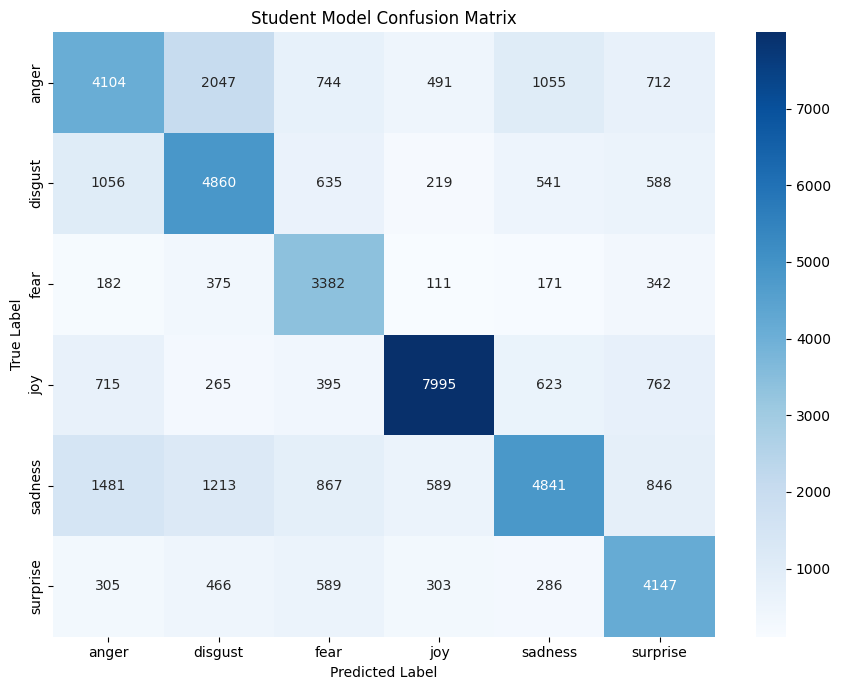

Executed cell #24


In [26]:
# ==========================================================
# CELL 24
# Plot confusion matrix
# ==========================================================

print("Starting cell #24")

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"]
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Student Model Confusion Matrix")
plt.tight_layout()
plt.show()

print("Executed cell #24")

In [27]:
# ==========================================================
# CELL 25
# Save or register final student model, tokenizer, label mapping, config,
# and print model size
# ==========================================================

print("Starting cell #25")

# In checkpoint/table-only mode, use the already loaded checkpoint path.
# In normal training mode, save the currently trained student model.
if student_model_loaded_from_checkpoint and loaded_student_checkpoint_path is not None:
    model_path = loaded_student_checkpoint_path
    final_student_dir = os.path.dirname(model_path)
    print("Using loaded pretrained checkpoint for size calculation:", model_path)
else:
    final_student_dir = os.path.join(SAVE_DIR, "final_student_model")
    os.makedirs(final_student_dir, exist_ok=True)

    base_student = get_base_model(student_model)
    model_path = os.path.join(final_student_dir, "student_model_state_dict.pt")

    torch.save(
        base_student.state_dict(),
        model_path
    )

    tokenizer.save_pretrained(final_student_dir)

    config = {
        "teacher_model_name": TEACHER_MODEL_NAME,
        "num_labels": NUM_LABELS,
        "id2label": id2label,
        "label2id": label2id,
        "max_length": MAX_LENGTH,
        "student_num_layers": STUDENT_NUM_LAYERS,
        "student_layer_selection": STUDENT_LAYER_SELECTION,
        "label_smoothing": LABEL_SMOOTHING,
        "temperature_kd": TEMPERATURE_KD,
        "row_align_temperature": ROW_ALIGN_TEMPERATURE,
        "supcon_temperature": SUPCON_TEMPERATURE,
        "class_weights": class_weights.tolist()
    }

    with open(os.path.join(final_student_dir, "training_config.json"), "w") as f:
        json.dump(config, f, indent=2)

model_size_bytes = os.path.getsize(model_path)
model_size_mb = model_size_bytes / (1024 ** 2)

base_student = get_base_model(student_model)
total_params = sum(p.numel() for p in base_student.parameters())
trainable_params = sum(p.numel() for p in base_student.parameters() if p.requires_grad)

print("\n================ MODEL INFO ================")
print("Student checkpoint path:", model_path)
print("Student checkpoint size (MB):", round(model_size_mb, 2))
print("Student package/folder size (MB):", round(directory_size_mb(final_student_dir), 2) if 'directory_size_mb' in globals() else "Run paper helper cell #26 for folder size")
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("============================================")

print("Executed cell #25")

Starting cell #25
Using loaded pretrained checkpoint for size calculation: /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/student_model_state_dict.pt

================ MODEL INFO ================
Student checkpoint path: /kaggle/working/previous_custom_model_output/emotion_kd_balanced_supcon/final_student_model/student_model_state_dict.pt
Student checkpoint size (MB): 896.23
Student package/folder size (MB): Run paper helper cell #26 for folder size
Total parameters: 234930438
Trainable parameters: 234930438
Executed cell #25


In [28]:
# ==========================================================
# PAPER TABLE GENERATION CELL 26
# Inline paper table helper functions
# ==========================================================

print("Starting paper table cell #26")

import time
from IPython.display import display, Markdown

# This notebook version displays every table directly under the cell output.
# It does NOT save the tables as CSV files by default.
INLINE_TABLE_OUTPUT_ONLY = True


def table_title_from_filename(filename):
    """Convert a previous CSV filename into a clean paper-table title."""
    if filename is None:
        return "Paper Table"
    title = str(filename)
    title = title.replace(".csv", "")
    title = title.replace("table_", "")
    title = title.replace("_", " ")
    return title.title()


def show_table(df, title=None, max_preview_rows=None):
    """Display a dataframe as a clean notebook output table."""
    if title:
        display(Markdown(f"### {title}"))

    if max_preview_rows is not None and len(df) > max_preview_rows:
        display(df.head(max_preview_rows))
        print(f"Showing first {max_preview_rows} rows out of {len(df)} total rows. Full table is stored in the dataframe variable.")
    else:
        display(df)

    return df


def display_table(df, title="Paper Table"):
    """Display a dataframe as a clean notebook output table."""
    return show_table(df, title=title)


# Backward-compatible alias in case you add older code later.
def save_table(df, filename=None, index=False):
    title = table_title_from_filename(filename)
    return display_table(df, title=title)


def directory_size_mb(path):
    """Return total directory size in MB."""
    total = 0
    if not os.path.exists(path):
        return np.nan
    for dirpath, _, filenames in os.walk(path):
        for filename in filenames:
            fp = os.path.join(dirpath, filename)
            if os.path.isfile(fp):
                total += os.path.getsize(fp)
    return total / (1024 ** 2)


def file_size_mb(path):
    if path is None or not os.path.exists(path):
        return np.nan
    return os.path.getsize(path) / (1024 ** 2)


def model_parameter_count(model):
    base_model = get_base_model(model)
    total_params = sum(p.numel() for p in base_model.parameters())
    trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    return total_params, trainable_params


def clean_float_columns(df, decimals=4):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].round(decimals)
    return out



def prediction_metrics_from_arrays(labels, preds):
    """Return accuracy, macro metrics, and weighted F1 from label/prediction arrays."""
    accuracy = accuracy_score(labels, preds)
    precision_macro, recall_macro, macro_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )
    precision_weighted, recall_weighted, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )
    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "weighted_f1": weighted_f1
    }

def metric_row(model_name, metrics, layers=None, size_mb=None, params=None, note=""):
    row = {
        "Model": model_name,
        "Layers": layers,
        "Accuracy": metrics.get("accuracy", np.nan),
        "Macro-Precision": metrics.get("precision_macro", np.nan),
        "Macro-Recall": metrics.get("recall_macro", np.nan),
        "Macro-F1": metrics.get("macro_f1", np.nan),
        "Weighted-F1": metrics.get("weighted_f1", np.nan),
        "Size (MB)": size_mb,
        "Parameters": params,
        "Note": note
    }
    return row

print("Inline table helper functions are ready. Tables will be displayed under each cell output, not saved as CSV files.")
print("Executed paper table cell #26")

Starting paper table cell #26
Inline table helper functions are ready. Tables will be displayed under each cell output, not saved as CSV files.
Executed paper table cell #26


In [29]:
# ==========================================================
# PAPER TABLE GENERATION CELL 27
# Dataset split, class distribution, and hyperparameter tables
# ==========================================================

print("Starting paper table cell #27")

# Dataset split table
split_rows = []
for split_name, original_df, flat_df in [
    ("Train", train_df, flat_train_df),
    ("Validation", val_df, flat_val_df),
    ("Test", test_df, flat_test_df),
]:
    split_rows.append({
        "Split": split_name,
        "Original rows": len(original_df),
        "Flattened sentences": len(flat_df),
        "Languages per row": NUM_LANGUAGES
    })

dataset_split_table = pd.DataFrame(split_rows)
display_table(dataset_split_table, "Dataset Split")

# Class distribution by split
class_dist_rows = []
for split_name, original_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    counts = original_df["label_id"].value_counts().sort_index()
    total = len(original_df)
    for class_id in range(NUM_LABELS):
        class_dist_rows.append({
            "Split": split_name,
            "Emotion": id2label[class_id],
            "Rows": int(counts.get(class_id, 0)),
            "Percent": 100.0 * counts.get(class_id, 0) / max(total, 1)
        })

class_distribution_table = pd.DataFrame(class_dist_rows)
display_table(clean_float_columns(class_distribution_table, 2), "Class Distribution by Split")

# Hyperparameter table for reproducibility
hyperparameter_rows = [
    ("Backbone", "teacher_model_name", TEACHER_MODEL_NAME),
    ("Architecture", "student_num_layers", STUDENT_NUM_LAYERS),
    ("Architecture", "student_layer_selection", str(STUDENT_LAYER_SELECTION)),
    ("Data", "max_length", MAX_LENGTH),
    ("Training", "seed", SEED),
    ("Training", "teacher_epochs", TEACHER_EPOCHS),
    ("Training", "student_epochs", STUDENT_EPOCHS),
    ("Training", "full_coverage_epochs", FULL_COVERAGE_EPOCHS),
    ("Training", "train_batch_size", TRAIN_BATCH_SIZE),
    ("Training", "eval_batch_size", EVAL_BATCH_SIZE),
    ("Training", "gradient_accumulation_steps", GRADIENT_ACCUMULATION_STEPS),
    ("Training", "gradient_clip", GRAD_CLIP),
    ("Optimization", "weight_decay", WEIGHT_DECAY),
    ("Optimization", "warmup_ratio", WARMUP_RATIO),
    ("Optimization", "teacher_encoder_lr", TEACHER_ENCODER_LR),
    ("Optimization", "teacher_head_lr", TEACHER_HEAD_LR),
    ("Optimization", "student_encoder_lr", STUDENT_ENCODER_LR),
    ("Optimization", "student_head_lr", STUDENT_HEAD_LR),
    ("Loss", "label_smoothing", LABEL_SMOOTHING),
    ("Loss", "temperature_kd", TEMPERATURE_KD),
    ("Loss", "alpha_kd", ALPHA_KD),
    ("Loss", "delta_embedding_kd", DELTA_EMBED_KD),
    ("Loss", "row_align_temperature", ROW_ALIGN_TEMPERATURE),
    ("Loss", "supcon_temperature", SUPCON_TEMPERATURE),
    ("Loss", "teacher_row_align_weight", TEACHER_ROW_ALIGN_WEIGHT),
    ("Loss", "teacher_supcon_weight", TEACHER_SUPCON_WEIGHT),
    ("Loss", "beta_row_align", BETA_ROW_ALIGN),
    ("Loss", "gamma_supcon", GAMMA_SUPCON),
    ("Balanced batch", "classes_per_batch", CLASSES_PER_BATCH),
    ("Balanced batch", "samples_per_class", SAMPLES_PER_CLASS),
    ("Balanced batch", "original_rows_per_balanced_batch", BALANCED_BATCH_SIZE),
    ("Balanced batch", "flattened_sentences_per_balanced_batch", BALANCED_BATCH_SIZE * NUM_LANGUAGES),
    ("Early stopping", "patience", EARLY_STOPPING_PATIENCE),
]

hyperparameter_table = pd.DataFrame(hyperparameter_rows, columns=["Category", "Parameter", "Value"])
display_table(hyperparameter_table, "Hyperparameters")

# Student loss schedule table
loss_schedule_rows = []
for epoch_idx in range(STUDENT_EPOCHS):
    if epoch_idx < FULL_COVERAGE_EPOCHS:
        stage = "full_coverage"
    else:
        stage = "balanced_supcon"

    if epoch_idx == 0:
        kd_weight = 0.20
        embed_kd_weight = 0.05
        row_weight = 0.00
        supcon_weight = 0.00
    elif epoch_idx == 1:
        kd_weight = ALPHA_KD
        embed_kd_weight = DELTA_EMBED_KD
        row_weight = BETA_ROW_ALIGN * 0.50
        supcon_weight = GAMMA_SUPCON * 0.50
    else:
        kd_weight = ALPHA_KD
        embed_kd_weight = DELTA_EMBED_KD
        row_weight = BETA_ROW_ALIGN
        supcon_weight = GAMMA_SUPCON

    loss_schedule_rows.append({
        "Epoch": epoch_idx + 1,
        "Stage": stage,
        "CE weight": 1.0,
        "KD weight": kd_weight,
        "Embedding KD weight": embed_kd_weight,
        "Row alignment weight": row_weight,
        "SupCon weight": supcon_weight
    })

loss_schedule_table = pd.DataFrame(loss_schedule_rows)
display_table(clean_float_columns(loss_schedule_table, 4), "Student Loss Weight Schedule")

print("Executed paper table cell #27")


Starting paper table cell #27


### Dataset Split

,Split,Original rows,Flattened sentences,Languages per row
0,Train,56067,168201,3
1,Validation,7929,23787,3
2,Test,16101,48303,3


### Class Distribution by Split

,Split,Emotion,Rows,Percent
0,Train,anger,10626,18.95
1,Train,disgust,9169,16.35
2,Train,fear,5295,9.44
3,Train,joy,12486,22.27
4,Train,sadness,11416,20.36
5,Train,surprise,7075,12.62
6,Validation,anger,1503,18.96
7,Validation,disgust,1297,16.36
8,Validation,fear,749,9.45
9,Validation,joy,1766,22.27


### Hyperparameters

,Category,Parameter,Value
0,Backbone,teacher_model_name,xlm-roberta-base
1,Architecture,student_num_layers,6
2,Architecture,student_layer_selection,"[0, 2, 4, 6, 8, 11]"
3,Data,max_length,128
4,Training,seed,42
5,Training,teacher_epochs,4
6,Training,student_epochs,6
7,Training,full_coverage_epochs,2
8,Training,train_batch_size,16
9,Training,eval_batch_size,64


### Student Loss Weight Schedule

,Epoch,Stage,CE weight,KD weight,Embedding KD weight,Row alignment weight,SupCon weight
0,1,full_coverage,1.0,0.2,0.05,0.00,0.000
1,2,full_coverage,1.0,0.4,0.10,0.05,0.025
2,3,balanced_supcon,1.0,0.4,0.10,0.10,0.050
3,4,balanced_supcon,1.0,0.4,0.10,0.10,0.050
4,5,balanced_supcon,1.0,0.4,0.10,0.10,0.050
5,6,balanced_supcon,1.0,0.4,0.10,0.10,0.050


Executed paper table cell #27


In [30]:
# ==========================================================
# PAPER TABLE GENERATION CELL 28
# Overall model comparison and deployable-size/parameter table
# ==========================================================

print("Starting paper table cell #28")

# Optional manual baseline row from your separate baseline notebook/paper.
# Change these values if you rerun the baseline notebook.
INCLUDE_MANUAL_BASELINE_ROW = True
BASELINE_XLMR_TEST_METRICS = {
    "accuracy": 0.6456,
    "precision_macro": 0.6426,
    "recall_macro": 0.6457,
    "macro_f1": 0.6428,
    "weighted_f1": 0.6448
}
BASELINE_XLMR_PACKAGE_SIZE_MB = 1058.50
BASELINE_XLMR_LAYERS = 12

# Reuse final student test metrics if Cell 23 has already generated them.
if "test_metrics" not in globals():
    test_metrics = evaluate_model(student_model, flat_test_loader)

student_test_metrics = test_metrics

# Teacher evaluation is optional because table-only mode may not load/train the teacher.
teacher_test_metrics = None
if EVALUATE_TEACHER_FOR_TABLES:
    teacher_test_metrics = evaluate_model(teacher_model, flat_test_loader)
else:
    print("Skipping teacher evaluation in Cell 28. Set EVALUATE_TEACHER_FOR_TABLES=True only if a trained teacher is loaded.")

comparison_rows = []

if INCLUDE_MANUAL_BASELINE_ROW and BASELINE_XLMR_TEST_METRICS is not None:
    comparison_rows.append(metric_row(
        "Full XLM-R baseline (from baseline notebook)",
        BASELINE_XLMR_TEST_METRICS,
        layers=BASELINE_XLMR_LAYERS,
        note="Manual row; update if the baseline notebook is rerun"
    ))

if teacher_test_metrics is not None:
    comparison_rows.append(metric_row(
        "Frozen teacher used for distillation",
        teacher_test_metrics,
        layers=12,
        note="Evaluated in this notebook"
    ))

comparison_rows.append(metric_row(
    "Proposed 6-layer contrastive student",
    student_test_metrics,
    layers=STUDENT_NUM_LAYERS,
    note="Loaded from checkpoint" if student_model_loaded_from_checkpoint else "Evaluated in this notebook"
))

overall_model_comparison_table = pd.DataFrame(comparison_rows)
display_table(clean_float_columns(overall_model_comparison_table, 4), "Overall Model Comparison")

# Model size and parameter table
student_total_params, student_trainable_params = model_parameter_count(student_model)

student_state_dict_mb = file_size_mb(model_path) if "model_path" in globals() else np.nan
student_package_mb = directory_size_mb(final_student_dir) if "final_student_dir" in globals() else np.nan

size_rows = []
if INCLUDE_MANUAL_BASELINE_ROW:
    size_rows.append({
        "Model": "Full XLM-R baseline (from baseline notebook)",
        "Layers": BASELINE_XLMR_LAYERS,
        "Total parameters": np.nan,
        "Trainable parameters": np.nan,
        "Checkpoint size (MB)": np.nan,
        "Deployable package size (MB)": BASELINE_XLMR_PACKAGE_SIZE_MB,
        "Reduction vs baseline (%)": 0.0,
        "Note": "Manual package-size row; update if baseline is rerun"
    })

if EVALUATE_TEACHER_FOR_TABLES:
    teacher_total_params, teacher_trainable_params = model_parameter_count(teacher_model)
    teacher_checkpoint_mb = file_size_mb(teacher_best_path)
    size_rows.append({
        "Model": "Frozen teacher used for distillation",
        "Layers": 12,
        "Total parameters": teacher_total_params,
        "Trainable parameters": teacher_trainable_params,
        "Checkpoint size (MB)": teacher_checkpoint_mb,
        "Deployable package size (MB)": np.nan,
        "Reduction vs baseline (%)": np.nan,
        "Note": "Teacher checkpoint only; package not saved"
    })

student_reduction = np.nan
if INCLUDE_MANUAL_BASELINE_ROW and BASELINE_XLMR_PACKAGE_SIZE_MB and not np.isnan(student_package_mb):
    student_reduction = 100.0 * (BASELINE_XLMR_PACKAGE_SIZE_MB - student_package_mb) / BASELINE_XLMR_PACKAGE_SIZE_MB

size_rows.append({
    "Model": "Proposed 6-layer contrastive student",
    "Layers": STUDENT_NUM_LAYERS,
    "Total parameters": student_total_params,
    "Trainable parameters": student_trainable_params,
    "Checkpoint size (MB)": student_state_dict_mb,
    "Deployable package size (MB)": student_package_mb,
    "Reduction vs baseline (%)": student_reduction,
    "Note": "Loaded checkpoint/package folder" if student_model_loaded_from_checkpoint else "Student package includes model checkpoint, tokenizer, and config files"
})

model_size_efficiency_table = pd.DataFrame(size_rows)
display_table(clean_float_columns(model_size_efficiency_table, 2), "Model Size and Parameters")

print("Executed paper table cell #28")

Starting paper table cell #28
Skipping teacher evaluation in Cell 28. Set EVALUATE_TEACHER_FOR_TABLES=True only if a trained teacher is loaded.


### Overall Model Comparison

,Model,Layers,Accuracy,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1,Size (MB),Parameters,Note
0,Full XLM-R baseline (from baseline notebook),12,0.6456,0.6426,0.6457,0.6428,0.6448,None,None,Manual row; update if the baseline notebook is...
1,Proposed 6-layer contrastive student,6,0.6072,0.5983,0.6201,0.6016,0.6067,None,None,Loaded from checkpoint


### Model Size and Parameters

,Model,Layers,Total parameters,Trainable parameters,Checkpoint size (MB),Deployable package size (MB),Reduction vs baseline (%),Note
0,Full XLM-R baseline (from baseline notebook),12,NaN,NaN,NaN,1058.50,0.00,Manual package-size row; update if baseline is...
1,Proposed 6-layer contrastive student,6,234930438.0,234930438.0,896.23,912.24,13.82,Loaded checkpoint/package folder


Executed paper table cell #28


In [31]:
# ==========================================================
# PAPER TABLE GENERATION CELL 29
# Inference speed / throughput table
# ==========================================================

print("Starting paper table cell #29")

@torch.inference_mode()
def benchmark_inference(model, data_loader, max_batches=50, warmup_batches=3):
    model.eval()

    # Warmup
    for batch_idx, batch in enumerate(data_loader):
        if batch_idx >= warmup_batches:
            break
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    total_sentences = 0
    start_time = time.time()

    for batch_idx, batch in enumerate(data_loader):
        if batch_idx >= max_batches:
            break
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        batch_size = input_ids.size(0)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            _ = model(input_ids=input_ids, attention_mask=attention_mask)

        total_sentences += batch_size

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.time()
    elapsed = max(end_time - start_time, 1e-12)

    return {
        "Evaluated sentences": total_sentences,
        "Elapsed time (s)": elapsed,
        "Sentences/second": total_sentences / elapsed,
        "Milliseconds/sentence": 1000.0 * elapsed / max(total_sentences, 1),
        "Device": str(device),
        "AMP enabled": AMP_ENABLED
    }

models_for_speed = []
if EVALUATE_TEACHER_FOR_TABLES:
    models_for_speed.append(("Frozen teacher used for distillation", teacher_model, 12))
else:
    print("Skipping teacher speed benchmark. Set EVALUATE_TEACHER_FOR_TABLES=True only if a trained teacher is loaded.")

models_for_speed.append(("Proposed 6-layer contrastive student", student_model, STUDENT_NUM_LAYERS))

speed_rows = []
for name, model, layers in models_for_speed:
    result = benchmark_inference(model, flat_test_loader, max_batches=50, warmup_batches=3)
    result["Model"] = name
    result["Layers"] = layers
    speed_rows.append(result)

inference_speed_table = pd.DataFrame(speed_rows)
ordered_cols = ["Model", "Layers", "Evaluated sentences", "Elapsed time (s)", "Sentences/second", "Milliseconds/sentence", "Device", "AMP enabled"]
inference_speed_table = inference_speed_table[ordered_cols]
display_table(clean_float_columns(inference_speed_table, 4), "Inference Speed")

print("Executed paper table cell #29")

Starting paper table cell #29
Skipping teacher speed benchmark. Set EVALUATE_TEACHER_FOR_TABLES=True only if a trained teacher is loaded.


### Inference Speed

,Model,Layers,Evaluated sentences,Elapsed time (s),Sentences/second,Milliseconds/sentence,Device,AMP enabled
0,Proposed 6-layer contrastive student,6,3200,4.9379,648.0499,1.5431,cuda,True


Executed paper table cell #29


In [32]:
# ==========================================================
# PAPER TABLE GENERATION CELL 30
# Language-wise performance, row-level consistency, and alignment metrics
# ==========================================================

print("Starting paper table cell #30")

# Safety helper: define metrics function here too, so Cell 30 works even if helper Cell 26 was skipped.
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

if "prediction_metrics_from_arrays" not in globals():
    def prediction_metrics_from_arrays(labels, preds):
        labels = np.asarray(labels)
        preds = np.asarray(preds)
        acc = accuracy_score(labels, preds)
        precision_macro, recall_macro, macro_f1, _ = precision_recall_fscore_support(
            labels, preds, average="macro", zero_division=0
        )
        precision_weighted, recall_weighted, weighted_f1, _ = precision_recall_fscore_support(
            labels, preds, average="weighted", zero_division=0
        )
        return {
            "accuracy": acc,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "macro_f1": macro_f1,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "weighted_f1": weighted_f1,
            # Extra aliases for safety if you reuse this elsewhere
            "Accuracy": acc,
            "Macro-Precision": precision_macro,
            "Macro-Recall": recall_macro,
            "Macro-F1": macro_f1,
            "Weighted-F1": weighted_f1
        }


@torch.inference_mode()
def evaluate_triplet_model_detailed(model, triplet_loader, model_name="model"):
    model.eval()

    row_records = []
    cosine_records = []

    for batch in tqdm(triplet_loader, desc=f"Triplet evaluation: {model_name}", leave=True):
        labels = batch["labels"].to(device, non_blocking=True)
        row_ids = batch["row_ids"].detach().cpu().numpy().tolist()

        outputs_by_lang = {}
        for lang_key in ["bangla", "banglish", "english"]:
            input_ids = batch[f"{lang_key}_input_ids"].to(device, non_blocking=True)
            attention_mask = batch[f"{lang_key}_attention_mask"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            logits = outputs["logits"]
            preds = torch.argmax(logits, dim=1)
            embeddings = F.normalize(outputs["embeddings"].float(), p=2, dim=1)

            outputs_by_lang[lang_key] = {
                "preds": preds.detach().cpu().numpy(),
                "embeddings": embeddings.detach().cpu()
            }

        labels_np = labels.detach().cpu().numpy()

        emb_bangla = outputs_by_lang["bangla"]["embeddings"]
        emb_banglish = outputs_by_lang["banglish"]["embeddings"]
        emb_english = outputs_by_lang["english"]["embeddings"]

        cos_bn_bg = F.cosine_similarity(emb_bangla, emb_banglish, dim=1).numpy()
        cos_bn_en = F.cosine_similarity(emb_bangla, emb_english, dim=1).numpy()
        cos_bg_en = F.cosine_similarity(emb_banglish, emb_english, dim=1).numpy()

        for i in range(len(labels_np)):
            pred_bn = int(outputs_by_lang["bangla"]["preds"][i])
            pred_bg = int(outputs_by_lang["banglish"]["preds"][i])
            pred_en = int(outputs_by_lang["english"]["preds"][i])
            true_label = int(labels_np[i])

            counts = Counter([pred_bn, pred_bg, pred_en])
            top_pred, top_count = counts.most_common(1)[0]
            majority_pred = int(top_pred) if top_count >= 2 else -1

            row_records.append({
                "row_id": int(row_ids[i]),
                "true_label_id": true_label,
                "true_label": id2label[true_label],
                "pred_bangla_id": pred_bn,
                "pred_bangla": id2label[pred_bn],
                "pred_banglish_id": pred_bg,
                "pred_banglish": id2label[pred_bg],
                "pred_english_id": pred_en,
                "pred_english": id2label[pred_en],
                "all_three_same": int(pred_bn == pred_bg == pred_en),
                "all_three_correct": int((pred_bn == true_label) and (pred_bg == true_label) and (pred_en == true_label)),
                "bangla_correct": int(pred_bn == true_label),
                "banglish_correct": int(pred_bg == true_label),
                "english_correct": int(pred_en == true_label),
                "bangla_banglish_agree": int(pred_bn == pred_bg),
                "bangla_english_agree": int(pred_bn == pred_en),
                "banglish_english_agree": int(pred_bg == pred_en),
                "has_majority": int(top_count >= 2),
                "majority_pred_id": majority_pred,
                "majority_pred": id2label[majority_pred] if majority_pred != -1 else "no_majority",
                "majority_correct": int(majority_pred == true_label) if majority_pred != -1 else 0,
                "cosine_bangla_banglish": float(cos_bn_bg[i]),
                "cosine_bangla_english": float(cos_bn_en[i]),
                "cosine_banglish_english": float(cos_bg_en[i])
            })

    row_prediction_df = pd.DataFrame(row_records)

    # Language-wise metrics from the same row-level predictions.
    language_rows = []
    language_specs = [
        ("Bangla", "pred_bangla_id"),
        ("Banglish", "pred_banglish_id"),
        ("English", "pred_english_id"),
    ]

    for language_name, pred_col in language_specs:
        m = prediction_metrics_from_arrays(row_prediction_df["true_label_id"], row_prediction_df[pred_col])
        language_rows.append({
            "Model": model_name,
            "Language": language_name,
            "Accuracy": m["accuracy"],
            "Macro-Precision": m["precision_macro"],
            "Macro-Recall": m["recall_macro"],
            "Macro-F1": m["macro_f1"],
            "Weighted-F1": m["weighted_f1"]
        })

    language_wise_df = pd.DataFrame(language_rows)

    # Row-level consistency metrics.
    row_summary = pd.DataFrame([{
        "Model": model_name,
        "Original test rows": len(row_prediction_df),
        "All three predictions same (%)": 100.0 * row_prediction_df["all_three_same"].mean(),
        "All three predictions correct (%)": 100.0 * row_prediction_df["all_three_correct"].mean(),
        "Bangla-Banglish agreement (%)": 100.0 * row_prediction_df["bangla_banglish_agree"].mean(),
        "Bangla-English agreement (%)": 100.0 * row_prediction_df["bangla_english_agree"].mean(),
        "Banglish-English agreement (%)": 100.0 * row_prediction_df["banglish_english_agree"].mean(),
        "Rows with majority vote (%)": 100.0 * row_prediction_df["has_majority"].mean(),
        "Majority-vote accuracy, tie as wrong (%)": 100.0 * row_prediction_df["majority_correct"].mean(),
        "Bangla accuracy (%)": 100.0 * row_prediction_df["bangla_correct"].mean(),
        "Banglish accuracy (%)": 100.0 * row_prediction_df["banglish_correct"].mean(),
        "English accuracy (%)": 100.0 * row_prediction_df["english_correct"].mean()
    }])

    # Embedding alignment metrics. Higher same-row cosine means stronger cross-language alignment.
    alignment_df = pd.DataFrame([{
        "Model": model_name,
        "Mean cosine: Bangla-Banglish": row_prediction_df["cosine_bangla_banglish"].mean(),
        "Mean cosine: Bangla-English": row_prediction_df["cosine_bangla_english"].mean(),
        "Mean cosine: Banglish-English": row_prediction_df["cosine_banglish_english"].mean(),
        "Average same-row cross-language cosine": row_prediction_df[[
            "cosine_bangla_banglish", "cosine_bangla_english", "cosine_banglish_english"
        ]].values.mean()
    }])

    return row_prediction_df, language_wise_df, row_summary, alignment_df

student_row_predictions, student_language_wise_table, student_row_consistency_table, student_alignment_table = evaluate_triplet_model_detailed(
    student_model,
    triplet_test_loader,
    model_name="Proposed 6-layer contrastive student"
)

display_table(clean_float_columns(student_language_wise_table, 4), "Language-Wise Student Performance")
display_table(clean_float_columns(student_row_consistency_table, 2), "Row-Level Consistency")
display_table(clean_float_columns(student_alignment_table, 4), "Embedding Alignment")

show_table(
    student_row_predictions,
    title="Student Row-Level Predictions Preview",
    max_preview_rows=20
)
print("\nFull row-level prediction details are available in the dataframe variable: student_row_predictions")

print("Executed paper table cell #30")


Starting paper table cell #30


Triplet evaluation: Proposed 6-layer contrastive student:   0%|          | 0/252 [00:00<?, ?it/s]

### Language-Wise Student Performance

,Model,Language,Accuracy,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1
0,Proposed 6-layer contrastive student,Bangla,0.6226,0.6126,0.6353,0.6166,0.6219
1,Proposed 6-layer contrastive student,Banglish,0.5935,0.5872,0.6062,0.5881,0.5942
2,Proposed 6-layer contrastive student,English,0.6054,0.5957,0.6188,0.6002,0.6040


### Row-Level Consistency

...

### Embedding Alignment

,Model,Mean cosine: Bangla-Banglish,Mean cosine: Bangla-English,Mean cosine: Banglish-English,Average same-row cross-language cosine
0,Proposed 6-layer contrastive student,0.8869,0.8779,0.855,0.8733


### Student Row-Level Predictions Preview

,row_id,true_label_id,true_label,pred_bangla_id,pred_bangla,pred_banglish_id,pred_banglish,pred_english_id,pred_english,all_three_same,...,bangla_banglish_agree,bangla_english_agree,banglish_english_agree,has_majority,majority_pred_id,majority_pred,majority_correct,cosine_bangla_banglish,cosine_bangla_english,cosine_banglish_english
0,0,3,joy,3,joy,3,joy,3,joy,1,...,1,1,1,1,3,joy,1,0.971983,0.968035,0.954752
1,1,3,joy,5,surprise,5,surprise,0,anger,0,...,1,0,0,1,5,surprise,0,0.933576,0.902081,0.855383
2,2,0,anger,5,surprise,5,surprise,4,sadness,0,...,1,0,0,1,5,surprise,0,0.945126,0.855774,0.852544
3,3,0,anger,1,disgust,1,disgust,1,disgust,1,...,1,1,1,1,1,disgust,0,0.807448,0.744932,0.667115
4,4,3,joy,4,sadness,4,sadness,1,disgust,0,...,1,0,0,1,4,sadness,0,0.799414,0.579021,0.677957
5,5,5,surprise,4,sadness,4,sadness,4,sadness,1,...,1,1,1,1,4,sadness,0,0.908952,0.866834,0.849743
6,6,1,disgust,5,surprise,5,surprise,5,surprise,1,...,1,1,1,1,5,surprise,0,0.921900,0.954779,0.935549
7,7,3,joy,5,surprise,5,surprise,4,sadness,0,...,1,0,0,1,5,surprise,0,0.828314,0.756308,0.686188
8,8,3,joy,3,joy,3,joy,3,joy,1,...,1,1,1,1,3,joy,1,0.882178,0.785073,0.791259
9,9,4,sadness,1,disgust,4,sadness,4,sadness,0,...,0,0,1,1,4,sadness,1,0.824259,0.888115,0.848893


Showing first 20 rows out of 16101 total rows. Full table is stored in the dataframe variable.

Full row-level prediction details are available in the dataframe variable: student_row_predictions
Executed paper table cell #30


Starting paper table cell #31


### Class-Wise Student Performance

,Emotion,Precision,Recall,F1-score,Support
0,anger,0.5233,0.4484,0.4829,9153
1,disgust,0.5268,0.6153,0.5676,7899
2,fear,0.5115,0.7412,0.6053,4563
3,joy,0.8235,0.7434,0.7814,10755
4,sadness,0.6440,0.4921,0.5579,9837
5,surprise,0.5606,0.6803,0.6147,6096


### Raw Confusion Matrix

,True label,anger,disgust,fear,joy,sadness,surprise
0,anger,4104,2047,744,491,1055,712
1,disgust,1056,4860,635,219,541,588
2,fear,182,375,3382,111,171,342
3,joy,715,265,395,7995,623,762
4,sadness,1481,1213,867,589,4841,846
5,surprise,305,466,589,303,286,4147


### Normalized Confusion Matrix

,True label,anger,disgust,fear,joy,sadness,surprise
0,anger,0.4484,0.2236,0.0813,0.0536,0.1153,0.0778
1,disgust,0.1337,0.6153,0.0804,0.0277,0.0685,0.0744
2,fear,0.0399,0.0822,0.7412,0.0243,0.0375,0.0750
3,joy,0.0665,0.0246,0.0367,0.7434,0.0579,0.0709
4,sadness,0.1506,0.1233,0.0881,0.0599,0.4921,0.0860
5,surprise,0.0500,0.0764,0.0966,0.0497,0.0469,0.6803


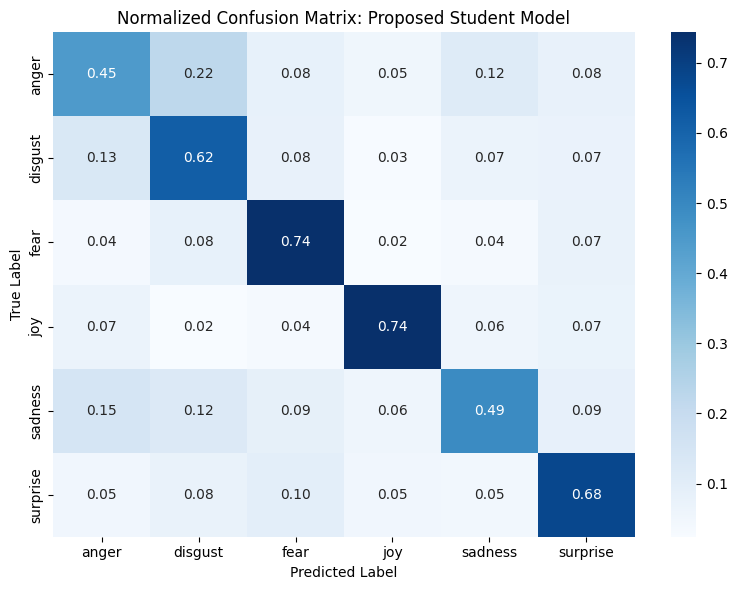

Displayed normalized confusion matrix figure under this cell.
Executed paper table cell #31


In [33]:
# ==========================================================
# PAPER TABLE GENERATION CELL 31
# Class-wise performance and normalized confusion matrix table/figure
# ==========================================================

print("Starting paper table cell #31")

target_names = [id2label[i] for i in range(NUM_LABELS)]

# Class-wise classification report
report_dict = classification_report(
    student_test_metrics["labels"],
    student_test_metrics["preds"],
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

classwise_rows = []
for class_name in target_names:
    classwise_rows.append({
        "Emotion": class_name,
        "Precision": report_dict[class_name]["precision"],
        "Recall": report_dict[class_name]["recall"],
        "F1-score": report_dict[class_name]["f1-score"],
        "Support": int(report_dict[class_name]["support"])
    })

classwise_performance_table = pd.DataFrame(classwise_rows)
display_table(clean_float_columns(classwise_performance_table, 4), "Class-Wise Student Performance")

# Raw and normalized confusion matrices
cm_raw = confusion_matrix(student_test_metrics["labels"], student_test_metrics["preds"])
cm_raw_df = pd.DataFrame(cm_raw, index=target_names, columns=target_names)
display_table(cm_raw_df.reset_index().rename(columns={"index": "True label"}), "Raw Confusion Matrix")

cm_normalized = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)
cm_normalized_df = pd.DataFrame(cm_normalized, index=target_names, columns=target_names)
display_table(clean_float_columns(cm_normalized_df.reset_index().rename(columns={"index": "True label"}), 4), "Normalized Confusion Matrix")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized_df,
    annot=True,
    fmt=".2f",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix: Proposed Student Model")
plt.tight_layout()
plt.show()
print("Displayed normalized confusion matrix figure under this cell.")

print("Executed paper table cell #31")


In [34]:
# ==========================================================
# PAPER TABLE GENERATION CELL 32
# Contrastive-learning effect table: train one extra student with contrastive losses disabled
# ==========================================================

print("Starting paper table cell #32")

# This cell trains ONE additional student from scratch with the contrastive losses disabled.
# It keeps CE + KD + Embedding KD, but disables Row Alignment and SupCon.
# Fast mode: the proposed contrastive student and teacher are loaded from your previous Kaggle output.
# Therefore, only this no-contrastive student is trained.

if "student_test_metrics" not in globals():
    if "test_metrics" in globals():
        student_test_metrics = test_metrics
    else:
        student_test_metrics = evaluate_model(student_model, flat_test_loader)

if "evaluate_triplet_model_detailed" not in globals():
    raise RuntimeError("Run Cell 30 before Cell 32. Cell 30 defines evaluate_triplet_model_detailed().")

# Make sure proposed-model language-invariance tables are available before freeing GPU memory.
if not all(name in globals() for name in ["student_language_wise_table", "student_row_consistency_table", "student_alignment_table"]):
    print("Proposed student triplet tables were not found. Evaluating proposed student now.")
    student_row_predictions, student_language_wise_table, student_row_consistency_table, student_alignment_table = evaluate_triplet_model_detailed(
        student_model,
        triplet_test_loader,
        model_name="Proposed 6-layer contrastive student"
    )


def train_student_without_contrastive_losses():
    """Train CE + KD + EmbKD student with row alignment and SupCon disabled."""
    print("\n" + "=" * 80)
    print("Training no-contrastive student: CE + KD + EmbKD only")
    print("Disabled losses: Row Alignment and SupCon")
    print("=" * 80)

    # Free GPU memory from already evaluated teacher/proposed-student models.
    # Their metrics/tables are already stored in dataframe variables.
    try:
        student_model.to("cpu")
        teacher_model.to("cpu")
    except Exception as memory_move_error:
        print("Warning: could not move existing models to CPU:", memory_move_error)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = XLMREmotionModel(
        model_name=TEACHER_MODEL_NAME,
        num_labels=NUM_LABELS,
        dropout=0.20,
        student_layers=STUDENT_LAYER_SELECTION
    ).to(device)

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    optimizer = build_optimizer(
        model,
        encoder_lr=STUDENT_ENCODER_LR,
        head_lr=STUDENT_HEAD_LR
    )

    steps_per_epoch = max(len(triplet_train_full_loader), len(triplet_train_balanced_loader))
    total_steps = steps_per_epoch * NO_CONTRASTIVE_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps
    )

    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    best_val_f1 = -1.0
    epochs_without_improvement = 0
    no_contrastive_best_path = os.path.join(SAVE_DIR, "best_student_no_contrastive.pt")

    for epoch in range(NO_CONTRASTIVE_EPOCHS):
        model.train()

        if epoch < FULL_COVERAGE_EPOCHS:
            current_loader = triplet_train_full_loader
            stage_name = "full_coverage"
        else:
            current_loader = triplet_train_balanced_loader
            stage_name = "balanced_batches_no_contrastive_loss"

        epoch_loss = 0.0
        progress_bar = tqdm(
            current_loader,
            desc=f"No-CL Student | Epoch {epoch + 1}/{NO_CONTRASTIVE_EPOCHS} [{stage_name}]",
            leave=True
        )

        for batch in progress_bar:
            labels = batch["labels"].to(device, non_blocking=True)

            bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
            bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)
            banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
            banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)
            english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
            english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
                out_bangla = model(input_ids=bangla_input_ids, attention_mask=bangla_attention_mask)
                out_banglish = model(input_ids=banglish_input_ids, attention_mask=banglish_attention_mask)
                out_english = model(input_ids=english_input_ids, attention_mask=english_attention_mask)

                student_logits_all = torch.cat([
                    out_bangla["logits"],
                    out_banglish["logits"],
                    out_english["logits"]
                ], dim=0)

                student_emb_all = torch.cat([
                    out_bangla["embeddings"],
                    out_banglish["embeddings"],
                    out_english["embeddings"]
                ], dim=0)

                labels_all = labels.repeat(3)

                teacher_logits_all = torch.cat([
                    batch["teacher_logits_bangla"].to(device, non_blocking=True),
                    batch["teacher_logits_banglish"].to(device, non_blocking=True),
                    batch["teacher_logits_english"].to(device, non_blocking=True)
                ], dim=0)

                teacher_emb_all = torch.cat([
                    batch["teacher_emb_bangla"].to(device, non_blocking=True),
                    batch["teacher_emb_banglish"].to(device, non_blocking=True),
                    batch["teacher_emb_english"].to(device, non_blocking=True)
                ], dim=0)

                ce_loss = classification_criterion(student_logits_all.float(), labels_all)
                kd_loss = knowledge_distillation_loss(
                    student_logits_all,
                    teacher_logits_all,
                    temperature=TEMPERATURE_KD
                )
                emb_kd_loss = embedding_distillation_loss(student_emb_all, teacher_emb_all)

                # Contrastive losses intentionally disabled here:
                # row_alignment_loss = 0 and supervised_contrastive_loss = 0
                total_loss = ce_loss + ALPHA_KD * kd_loss + DELTA_EMBED_KD * emb_kd_loss

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            epoch_loss += total_loss.item()
            progress_bar.set_postfix({
                "loss": f"{total_loss.item():.4f}",
                "ce": f"{ce_loss.item():.4f}",
                "kd": f"{kd_loss.item():.4f}",
                "emb": f"{emb_kd_loss.item():.4f}"
            })

        val_metrics_no_cl = evaluate_model(model, flat_val_loader)
        avg_epoch_loss = epoch_loss / max(len(current_loader), 1)

        print(
            f"No-CL validation Macro-F1: {val_metrics_no_cl['macro_f1']:.4f} | "
            f"Weighted-F1: {val_metrics_no_cl['weighted_f1']:.4f} | "
            f"Loss: {avg_epoch_loss:.4f}"
        )

        if val_metrics_no_cl["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics_no_cl["macro_f1"]
            epochs_without_improvement = 0
            torch.save(get_base_model(model).state_dict(), no_contrastive_best_path)
            print("Best no-contrastive student saved:", no_contrastive_best_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= NO_CONTRASTIVE_EARLY_STOPPING_PATIENCE:
            print("Early stopping no-contrastive student training.")
            break

    get_base_model(model).load_state_dict(torch.load(no_contrastive_best_path, map_location=device))

    no_cl_test_metrics = evaluate_model(model, flat_test_loader)
    no_cl_row_predictions, no_cl_language_wise_table, no_cl_row_consistency_table, no_cl_alignment_table = evaluate_triplet_model_detailed(
        model,
        triplet_test_loader,
        model_name="6-layer student without contrastive losses"
    )

    return model, best_val_f1, no_cl_test_metrics, no_cl_row_predictions, no_cl_language_wise_table, no_cl_row_consistency_table, no_cl_alignment_table


if RUN_CONTRASTIVE_DISABLED_COMPARISON:
    no_contrastive_model, no_contrastive_best_val_f1, no_contrastive_test_metrics, no_contrastive_row_predictions, no_contrastive_language_wise_table, no_contrastive_row_consistency_table, no_contrastive_alignment_table = train_student_without_contrastive_losses()

    # Overall performance: directly shows what happens when contrastive losses are disabled.
    contrastive_effect_overall_table = pd.DataFrame([
        {
            "Model": "6-layer student without contrastive losses",
            "CE": True,
            "KD": True,
            "Embedding KD": True,
            "Row alignment": False,
            "SupCon": False,
            "Best validation Macro-F1": no_contrastive_best_val_f1,
            "Test Accuracy": no_contrastive_test_metrics["accuracy"],
            "Test Macro-F1": no_contrastive_test_metrics["macro_f1"],
            "Test Weighted-F1": no_contrastive_test_metrics["weighted_f1"]
        },
        {
            "Model": "Proposed 6-layer contrastive student",
            "CE": True,
            "KD": True,
            "Embedding KD": True,
            "Row alignment": True,
            "SupCon": True,
            "Best validation Macro-F1": best_student_f1 if "best_student_f1" in globals() else np.nan,
            "Test Accuracy": student_test_metrics["accuracy"],
            "Test Macro-F1": student_test_metrics["macro_f1"],
            "Test Weighted-F1": student_test_metrics["weighted_f1"]
        }
    ])

    baseline_accuracy = contrastive_effect_overall_table.loc[0, "Test Accuracy"]
    baseline_macro_f1 = contrastive_effect_overall_table.loc[0, "Test Macro-F1"]
    baseline_weighted_f1 = contrastive_effect_overall_table.loc[0, "Test Weighted-F1"]

    contrastive_effect_overall_table["Delta Accuracy vs No-CL"] = contrastive_effect_overall_table["Test Accuracy"] - baseline_accuracy
    contrastive_effect_overall_table["Delta Macro-F1 vs No-CL"] = contrastive_effect_overall_table["Test Macro-F1"] - baseline_macro_f1
    contrastive_effect_overall_table["Delta Weighted-F1 vs No-CL"] = contrastive_effect_overall_table["Test Weighted-F1"] - baseline_weighted_f1

    display_table(clean_float_columns(contrastive_effect_overall_table, 4), "Effect of Contrastive Learning on Overall Test Performance")

    # Language-wise comparison.
    contrastive_effect_language_table = pd.concat(
        [no_contrastive_language_wise_table, student_language_wise_table],
        ignore_index=True
    )
    display_table(clean_float_columns(contrastive_effect_language_table, 4), "Effect of Contrastive Learning on Language-Wise Performance")

    # Compact language-invariance table for Results section.
    def summarize_language_invariance(model_name, language_table, row_consistency_table, alignment_table):
        return {
            "Model": model_name,
            "Mean language Macro-F1": language_table["Macro-F1"].mean(),
            "Minimum language Macro-F1": language_table["Macro-F1"].min(),
            "All three predictions same (%)": row_consistency_table["All three predictions same (%)"].iloc[0],
            "All three predictions correct (%)": row_consistency_table["All three predictions correct (%)"].iloc[0],
            "Majority-vote accuracy (%)": row_consistency_table["Majority-vote accuracy, tie as wrong (%)"].iloc[0],
            "Average same-row cross-language cosine": alignment_table["Average same-row cross-language cosine"].iloc[0]
        }

    contrastive_effect_invariance_table = pd.DataFrame([
        summarize_language_invariance(
            "6-layer student without contrastive losses",
            no_contrastive_language_wise_table,
            no_contrastive_row_consistency_table,
            no_contrastive_alignment_table
        ),
        summarize_language_invariance(
            "Proposed 6-layer contrastive student",
            student_language_wise_table,
            student_row_consistency_table,
            student_alignment_table
        )
    ])

    no_cl_inv_baseline = contrastive_effect_invariance_table.iloc[0]
    for col in [
        "Mean language Macro-F1",
        "Minimum language Macro-F1",
        "All three predictions same (%)",
        "All three predictions correct (%)",
        "Majority-vote accuracy (%)",
        "Average same-row cross-language cosine"
    ]:
        contrastive_effect_invariance_table[f"Delta {col} vs No-CL"] = contrastive_effect_invariance_table[col] - no_cl_inv_baseline[col]

    display_table(clean_float_columns(contrastive_effect_invariance_table, 4), "Effect of Contrastive Learning on Language-Invariant Behavior")

    print("\nImportant interpretation note:")
    print("Use these tables to support the claim only if the proposed contrastive student improves the relevant metrics.")
    print("If overall accuracy does not improve but row consistency/cosine alignment improves, write that contrastive learning mainly improved alignment/consistency rather than raw accuracy.")
else:
    contrastive_disabled_comparison_template = pd.DataFrame([
        {
            "Model": "6-layer student without contrastive losses",
            "CE": True,
            "KD": True,
            "Embedding KD": True,
            "Row alignment": False,
            "SupCon": False,
            "Status": "Not run. Set RUN_CONTRASTIVE_DISABLED_COMPARISON = True."
        },
        {
            "Model": "Proposed 6-layer contrastive student",
            "CE": True,
            "KD": True,
            "Embedding KD": True,
            "Row alignment": True,
            "SupCon": True,
            "Status": "Already trained in Cell 22."
        }
    ])
    display_table(contrastive_disabled_comparison_template, "Contrastive Disabled Comparison Template")

print("Executed paper table cell #32")


Starting paper table cell #32

Training no-contrastive student: CE + KD + EmbKD only
Disabled losses: Row Alignment and SupCon


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.dense.bias          | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


No-CL Student | Epoch 1/6 [full_coverage]:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]

...

### Effect of Contrastive Learning on Language-Wise Performance

,Model,Language,Accuracy,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1
0,6-layer student without contrastive losses,Bangla,0.6192,0.6103,0.6310,0.6144,0.6175
1,6-layer student without contrastive losses,Banglish,0.5864,0.5813,0.5986,0.5814,0.5867
2,6-layer student without contrastive losses,English,0.6066,0.5975,0.6187,0.6014,0.6050
3,Proposed 6-layer contrastive student,Bangla,0.6226,0.6126,0.6353,0.6166,0.6219
4,Proposed 6-layer contrastive student,Banglish,0.5935,0.5872,0.6062,0.5881,0.5942
5,Proposed 6-layer contrastive student,English,0.6054,0.5957,0.6188,0.6002,0.6040


### Effect of Contrastive Learning on Language-Invariant Behavior

,Model,Mean language Macro-F1,Minimum language Macro-F1,All three predictions same (%),All three predictions correct (%),Majority-vote accuracy (%),Average same-row cross-language cosine,Delta Mean language Macro-F1 vs No-CL,Delta Minimum language Macro-F1 vs No-CL,Delta All three predictions same (%) vs No-CL,Delta All three predictions correct (%) vs No-CL,Delta Majority-vote accuracy (%) vs No-CL,Delta Average same-row cross-language cosine vs No-CL
0,6-layer student without contrastive losses,0.5991,0.5814,58.4187,45.1152,60.9900,0.8675,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Proposed 6-layer contrastive student,0.6016,0.5881,59.7230,45.9040,61.3254,0.8733,0.0026,0.0067,1.3043,0.7888,0.3354,0.0058



Important interpretation note:
Use these tables to support the claim only if the proposed contrastive student improves the relevant metrics.
If overall accuracy does not improve but row consistency/cosine alignment improves, write that contrastive learning mainly improved alignment/consistency rather than raw accuracy.
Executed paper table cell #32


In [35]:
# ==========================================================
# PAPER TABLE GENERATION CELL 33
# Final note for inline table outputs
# ==========================================================

print("Starting paper table cell #33")

print("\nAll paper tables are displayed directly under their generating cells.")
print("No CSV table files are saved in this notebook version.")
print("\nMain dataframe variables available after running the paper-table cells:")
main_tables = [
    "dataset_split_table",
    "class_distribution_table",
    "hyperparameter_table",
    "student_loss_schedule_table",
    "overall_comparison_table",
    "size_parameter_table",
    "inference_speed_table",
    "student_language_wise_table",
    "student_row_consistency_table",
    "student_alignment_table",
    "classwise_performance_table",
    "cm_raw_df",
    "cm_normalized_df",
    "student_row_predictions",
    "contrastive_effect_overall_table",
    "contrastive_effect_language_table",
    "contrastive_effect_invariance_table"
]
for table_name in main_tables:
    print("-", table_name)

print("\nUse the displayed tables directly for your Results, Discussion, Limitations, and Methodology sections.")
print("Executed paper table cell #33")

Starting paper table cell #33

All paper tables are displayed directly under their generating cells.
No CSV table files are saved in this notebook version.

Main dataframe variables available after running the paper-table cells:
- dataset_split_table
- class_distribution_table
- hyperparameter_table
- student_loss_schedule_table
- overall_comparison_table
- size_parameter_table
- inference_speed_table
- student_language_wise_table
- student_row_consistency_table
- student_alignment_table
- classwise_performance_table
- cm_raw_df
- cm_normalized_df
- student_row_predictions
- contrastive_effect_overall_table
- contrastive_effect_language_table
- contrastive_effect_invariance_table

Use the displayed tables directly for your Results, Discussion, Limitations, and Methodology sections.
Executed paper table cell #33
